## AUTHOR : OM CHOKSI

### Obesity

Obesity, which causes physical and mental problems, is a global health problem with serious consequences. The prevalence of obesity is increasing steadily, and therefore, new research is needed that examines the influencing factors of obesity and how to predict the occurrence of the condition according to these factors.

" https://www.semanticscholar.org/paper/Estimation-of-Obesity-Levels-with-a-Trained-Neural-Ya%C4%9F%C4%B1n-G%C3%BCl%C3%BC/2c1eab51db154493d225c8b86ba885bbaf147a2c "

Dataset Information

This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

Gender: Feature, Categorical, "Gender"
Age : Feature, Continuous, "Age"
Height: Feature, Continuous
Weight: Feature Continuous
family_history_with_overweight: Feature, Binary, " Has a family member suffered or suffers from overweight? "

FAVC : Feature, Binary, " Do you eat high caloric food frequently? "
FCVC : Feature, Integer, " Do you usually eat vegetables in your meals? "
NCP : Feature, Continuous, " How many main meals do you have daily? "
CAEC : Feature, Categorical, " Do you eat any food between meals? "
SMOKE : Feature, Binary, " Do you smoke? "
CH2O: Feature, Continuous, " How much water do you drink daily? "
SCC: Feature, Binary, " Do you monitor the calories you eat daily? "
FAF: Feature, Continuous, " How often do you have physical activity? "
TUE : Feature, Integer, " How much time do you use technological devices such as cell phone, videogames, television, computer and others? "

CALC : Feature, Categorical, " How often do you drink alcohol? "
MTRANS : Feature, Categorical, " Which transportation do you usually use? "
NObeyesdad : Target, Categorical, "Obesity level"

**Aim**
- I made this version for my practise , So The Start is Very basic , Data is Pure From Null Values only Some Duplicate There , Which Were Removed.
- The EDA Version Contains Just Visualizations , Not any Observations.
- The Normalization is Done With The Help of Quantile transformer.
- Encoding is Done By Pandas [ pd.get_dummies ].
- Then The Params are Tunned by Optuna , I did't Add The Optune Code There.

##  About Data

## Dataset Description

The dataset for this competition (both train and test) was generated from a deep learning model trained on the Obesity or CVD risk dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

**Note:** This dataset is particularly well suited for visualizations, clustering, and general EDA. Show off your skills!

### Files
- **train.csv**: the training dataset; NObeyesdad is the categorical target
- **test.csv**: the test dataset; your objective is to predict the class of NObeyesdad for each row
- **sample_submission.csv**: a sample submission file in the correct format


## Step 1 | Importing Data & Libraries

In [113]:
# !python -m ipykernel install --user --name play --display-name "Python (play)"

In [114]:
# Import Basis
import pandas as pd
import optuna
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from colorama import Fore, Style, init;

from IPython.display import display, HTML
from scipy.stats import skew  # Import the skew function
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, VotingRegressor
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler , StandardScaler , QuantileTransformer
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from catboost import CatBoostClassifier
from sklearn.metrics import *
palette = ["#00B1D2FF", "#FDDB27FF"]
color_palette = sns.color_palette(palette)
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

## Step 2 | Loading Data</p>

In [115]:
# Load Submission Data
d_s = pd.read_csv('sample_submission.csv')
d_s.head()

,id,NObeyesdad
0,20758,Normal_Weight
1,20759,Normal_Weight
2,20760,Normal_Weight
3,20761,Normal_Weight
4,20762,Normal_Weight


In [116]:
# Load test Data
te_d = pd.read_csv('test.csv')
te_d.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,20758,Male,26.899886,1.848294,120.644178,yes,yes,2.938616,3.000000,Sometimes,no,2.825629,no,0.855400,0.000000,Sometimes,Public_Transportation
1,20759,Female,21.000000,1.600000,66.000000,yes,yes,2.000000,1.000000,Sometimes,no,3.000000,no,1.000000,0.000000,Sometimes,Public_Transportation
2,20760,Female,26.000000,1.643355,111.600553,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.250502,Sometimes,Public_Transportation
3,20761,Male,20.979254,1.553127,103.669116,yes,yes,2.000000,2.977909,Sometimes,no,2.786417,no,0.094851,0.000000,Sometimes,Public_Transportation
4,20762,Female,26.000000,1.627396,104.835346,yes,yes,3.000000,3.000000,Sometimes,no,2.653531,no,0.000000,0.741069,Sometimes,Public_Transportation


In [117]:
#Train Data
tr_d = pd.read_csv('train.csv')
tr_d.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [118]:

# Orignal Data
O_D = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
O_D.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [119]:
# Dropping Id from  Train
tr_d.drop(columns=['id'], inplace=True)
te_d.drop(columns=['id'], inplace=True)

In [120]:
# Concat Train and Original Data
tr_d = pd.concat([tr_d, O_D], ignore_index=True)

tr_d.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


### Optional task for output formatting

In [121]:
# Text Color
def PrintColor(text: str, color=Fore.CYAN, style=Style.BRIGHT):
    "Prints color outputs using colorama using a text F-string"
    print(style + color + text + Style.RESET_ALL)

# Text For Main Heading
def print_blue_large(text):
    PrintColor(text, Fore.BLUE + Style.BRIGHT)

# Main Heading
def print_boxed_blue_heading(text):
    length = len(text) + 4
    print(f"\n{Style.BRIGHT}{Fore.BLUE}{'='*length}{Style.RESET_ALL}")
    print(f"{Style.BRIGHT}{Fore.BLUE}| {text} |{Style.RESET_ALL}")
    print(f"{Style.BRIGHT}{Fore.BLUE}{'='*length}{Style.RESET_ALL}")

## Step 3 Data overview

**Use Case Of this Function**

- This Function Will Help to Load and Give a Overview of Data.
- This Functions Takes Data as Inputs and Given all the Information about Data Like Head , shape , Info , Describe , Null Values and Duplicates Values etc.

In [122]:
def data_overview(tr_d, te_d):

    # Display head of the training dataset nicely
    print_boxed_blue_heading("The Head Of Train Dataset is:")
    display(HTML(tr_d.head(5).to_html(index=False).replace('<table border="1" class="dataframe">', '<table style="border: 2px solid blue;">')))

    print('\n')

    # Display head of the test dataset nicely
    print_boxed_blue_heading("The Head Of Test Dataset is:")
    display(HTML(te_d.head(5).to_html(index=False).replace('<table border="1" class="dataframe">', '<table style="border: 2px solid blue;">')))

    print('\n')

    # Shapes of Train and Test
    print_boxed_blue_heading("Shape Information:")
    PrintColor(f"The Shape Of Train Data is {tr_d.shape} || No of Rows is : {tr_d.shape[0]} and Columns is {tr_d.shape[1]}", Fore.CYAN)
    print('\n')
    PrintColor(f"The Shape Of Test Data is {te_d.shape}  || No of Rows is : {te_d.shape[0]} and Columns is {te_d.shape[1]}", Fore.CYAN)
    print('\n')

    # Info of Both Datasets
    print_boxed_blue_heading("Dataset Information:")
    PrintColor(f"\nThe Info Of Train Dataset", Fore.CYAN)
    tr_d.info()
    PrintColor(f"\nThe Info Of Test Dataset is", Fore.CYAN)
    te_d.info()
    print('\n')

    # Describe Both
    print_boxed_blue_heading("Numerical Summary:")
    PrintColor(f"\nThe Numerical Summary of Train is", Fore.CYAN)
    display(tr_d.describe().style.set_caption("Train Data Summary").set_table_styles([{'selector': 'caption', 'props': [('color', 'blue')]}]))
    PrintColor(f"\nThe Numerical Summary of Test is", Fore.CYAN)
    display(te_d.describe().style.set_caption("Test Data Summary").set_table_styles([{'selector': 'caption', 'props': [('color', 'blue')]}]))
    print('\n')

    # Null Values in Train and Test
    print_boxed_blue_heading("Null Values:")
    PrintColor("\nNull Values in Train", Fore.CYAN)
    print(tr_d.isnull().sum())
    PrintColor("\nNull Values in Test", Fore.CYAN)
    print(te_d.isnull().sum())
    print('\n')

    # Duplicates Values in Train and Test
    print_boxed_blue_heading("Duplicate Values:")
    PrintColor("\nDuplicates Values in Train", Fore.CYAN)
    print(tr_d.duplicated().sum())
    PrintColor("\nDuplicates Values in Test", Fore.CYAN)
    print(te_d.duplicated().sum())

In [123]:
# Data Overview
data_overview(tr_d,te_d)


| The Head Of Train Dataset is: |


Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II





| The Head Of Test Dataset is: |


Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
Male,26.899886,1.848294,120.644178,yes,yes,2.938616,3.000000,Sometimes,no,2.825629,no,0.855400,0.000000,Sometimes,Public_Transportation
Female,21.000000,1.600000,66.000000,yes,yes,2.000000,1.000000,Sometimes,no,3.000000,no,1.000000,0.000000,Sometimes,Public_Transportation
Female,26.000000,1.643355,111.600553,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.250502,Sometimes,Public_Transportation
Male,20.979254,1.553127,103.669116,yes,yes,2.000000,2.977909,Sometimes,no,2.786417,no,0.094851,0.000000,Sometimes,Public_Transportation
Female,26.000000,1.627396,104.835346,yes,yes,3.000000,3.000000,Sometimes,no,2.653531,no,0.000000,0.741069,Sometimes,Public_Transportation





| Shape Information: |
The Shape Of Train Data is (22869, 17) || No of Rows is : 22869 and Columns is 17


The Shape Of Test Data is (13840, 16)  || No of Rows is : 13840 and Columns is 16



| Dataset Information: |

The Info Of Train Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22869 entries, 0 to 22868
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          22869 non-null  object 
 1   Age                             22869 non-null  float64
 2   Height                          22869 non-null  float64
 3   Weight                          22869 non-null  float64
 4   family_history_with_overweight  22869 non-null  object 
 5   FAVC                            22869 non-null  object 
 6   FCVC                            22869 non-null  float64
 7   NCP                             22869 non-null  float64
 8   CAEC                         

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,22869.000000,22869.000000,22869.000000,22869.000000,22869.000000,22869.000000,22869.000000,22869.000000
mean,23.885263,1.700377,87.767610,2.443428,2.754344,2.027442,0.984382,0.620551
std,5.753419,0.087881,26.364243,0.533329,0.712711,0.608901,0.839466,0.602850
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.631662,66.000000,2.000000,3.000000,1.755907,0.015860,0.000000
50%,22.815416,1.700000,84.000000,2.392665,3.000000,2.000000,1.000000,0.579541
75%,26.000000,1.763029,111.531208,3.000000,3.000000,2.535127,1.596576,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



The Numerical Summary of Test is


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,13840.000000,13840.000000,13840.000000,13840.000000,13840.000000,13840.000000,13840.000000,13840.000000
mean,23.952740,1.698934,87.384504,2.442898,2.750610,2.032044,0.974532,0.611033
std,5.799814,0.088761,26.111819,0.531606,0.710927,0.611230,0.840361,0.608005
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.631662,65.000000,2.000000,3.000000,1.771781,0.001086,0.000000
50%,22.906342,1.700000,83.952968,2.358087,3.000000,2.000000,1.000000,0.552498
75%,26.000000,1.760710,111.157811,3.000000,3.000000,2.552388,1.571865,1.000000
max,61.000000,1.980000,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000





| Null Values: |

Null Values in Train
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Null Values in Test
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                    

**Data Have No Null Values and Have Some  Duplicates**

In [124]:
# Drop Duplicates
tr_d.drop_duplicates(inplace=True)

## Step 4 | Feature Engineering

In [125]:
def Feature_E(df):
    # Feature 1: BMI (Body Mass Index)
    df['BMI'] = df['Weight'] / (df['Height'] / 100)**2

    # Feature 2: Number of meals per day
    df['Meals_Per_Day'] = df['FCVC'] + df['NCP']

    # Feature 3: Total physical activity score
    df['Total_Activity_Score'] = df['FAF'] * df['TUE']

    # Feature 5: Age category (e.g., young, adult, elderly)
    df['Age_Category'] = pd.cut(df['Age'], bins=[0, 18, 60, float('inf')], labels=['Young', 'Adult', 'Elderly'])

    # Feature 6: Water intake per kg of body weight
    df['Water_Intake_Per_Kg'] = df['CH2O'] / df['Weight']

    return df



In [126]:
# Apply the feature engineering function to your training and testing datasets
tr_d = Feature_E(tr_d)
te_d = Feature_E(te_d)

## Step 5 | EDA

#### Univariate

### categorical data

In [127]:

def single_plot_distribution(column_name, dataframe):

    value_counts = dataframe[column_name].value_counts()


    # Set up the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1]})

    # Donut pie chart
    pie_colors = palette[0:3]
    ax1.pie(value_counts, autopct='%0.001f%%', startangle=90, pctdistance=0.85, colors=pie_colors, labels=None)
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax1.add_artist(centre_circle)
    ax1.set_title(f'Distribution of {column_name}', fontsize=16)

    # Bar chart
    bar_colors = palette[0:3]
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax2, palette=bar_colors,)
    ax2.set_title(f'Count of {column_name}', fontsize=16)
    ax2.set_xlabel(column_name, fontsize=14)
    ax2.set_ylabel('Count', fontsize=14)

    # Rotate x-axis labels for better readability
    ax2.tick_params(axis='x', rotation=45)


    plt.tight_layout()
    # plt.savefig(f'fig/{column_name}_distribution.png')
    plt.show()

In [128]:
tr_d.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad', 'BMI', 'Meals_Per_Day',
       'Total_Activity_Score', 'Age_Category', 'Water_Intake_Per_Kg'],
      dtype='object')

In [129]:
num_tr_d = tr_d.select_dtypes(include=np.number).columns
num_tr_d

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI',
       'Meals_Per_Day', 'Total_Activity_Score', 'Water_Intake_Per_Kg'],
      dtype='object')

In [130]:
cat_tr_d = tr_d.select_dtypes(exclude=np.number).columns
cat_tr_d

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad', 'Age_Category'],
      dtype='object')

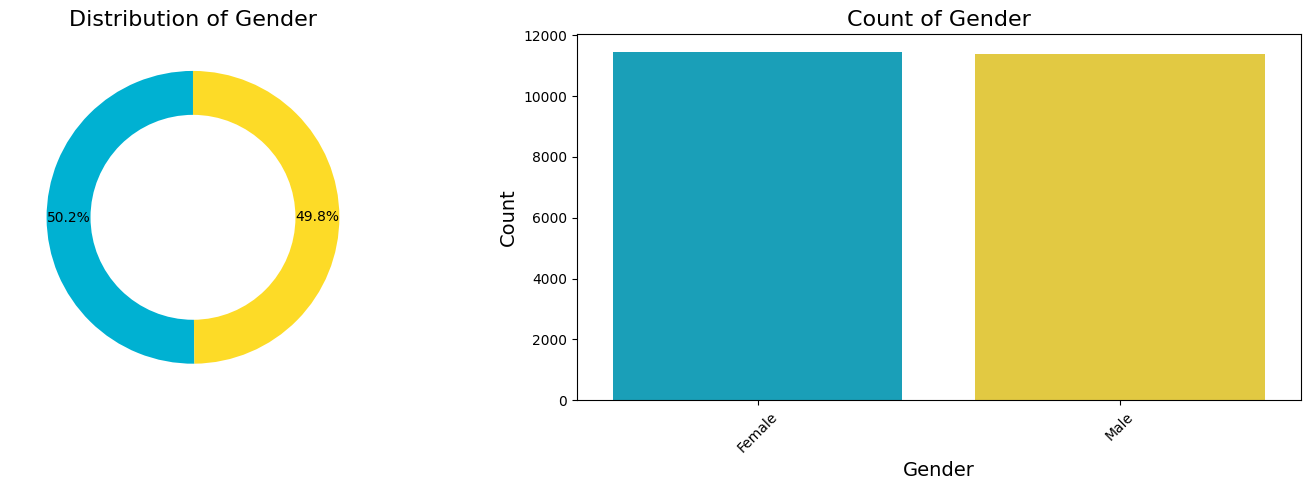

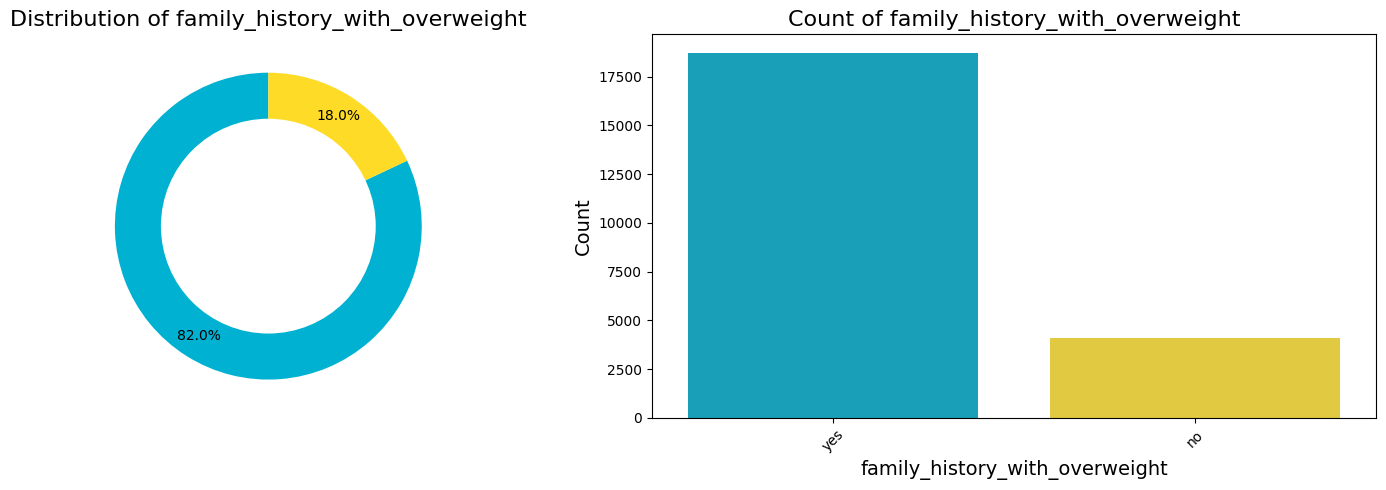

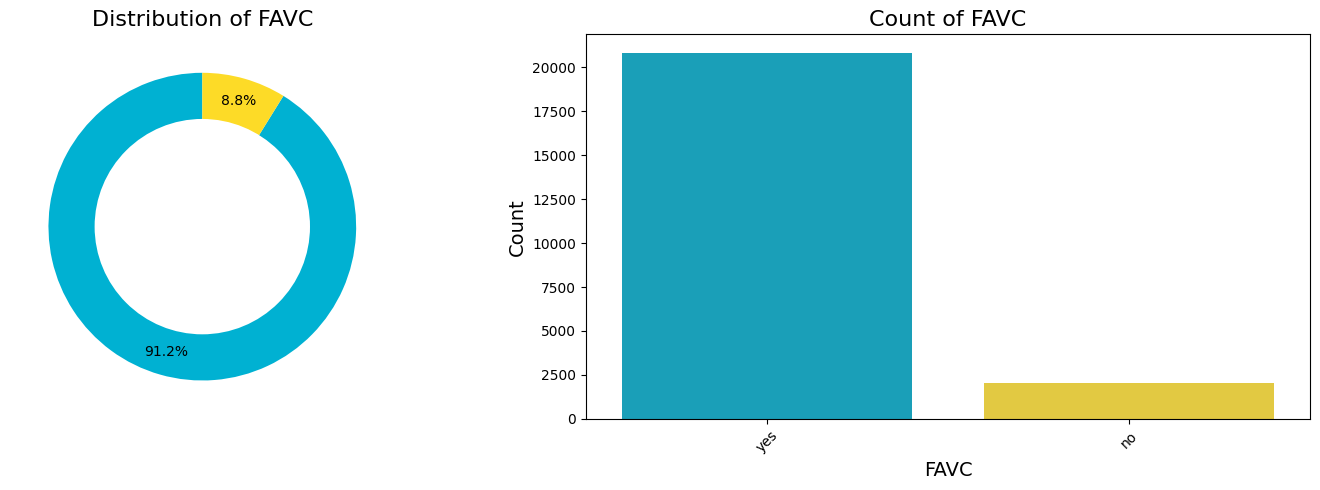

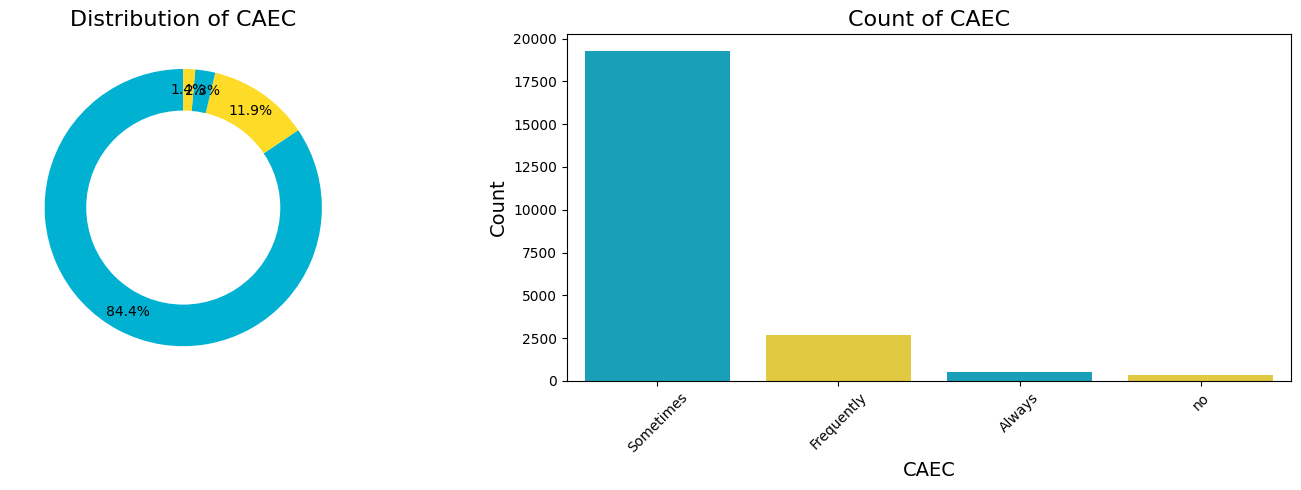

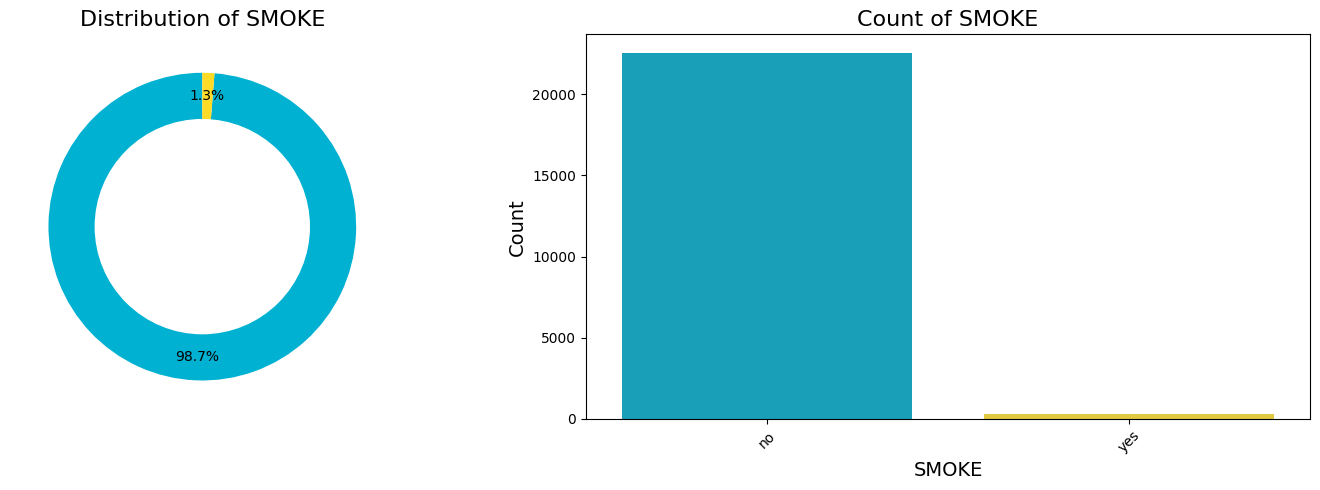

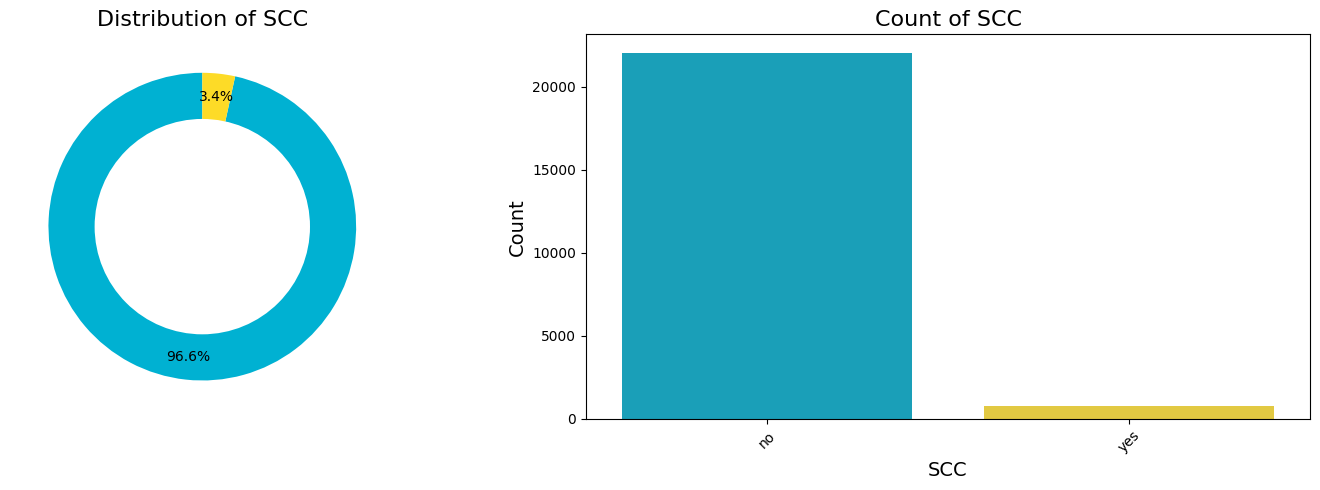

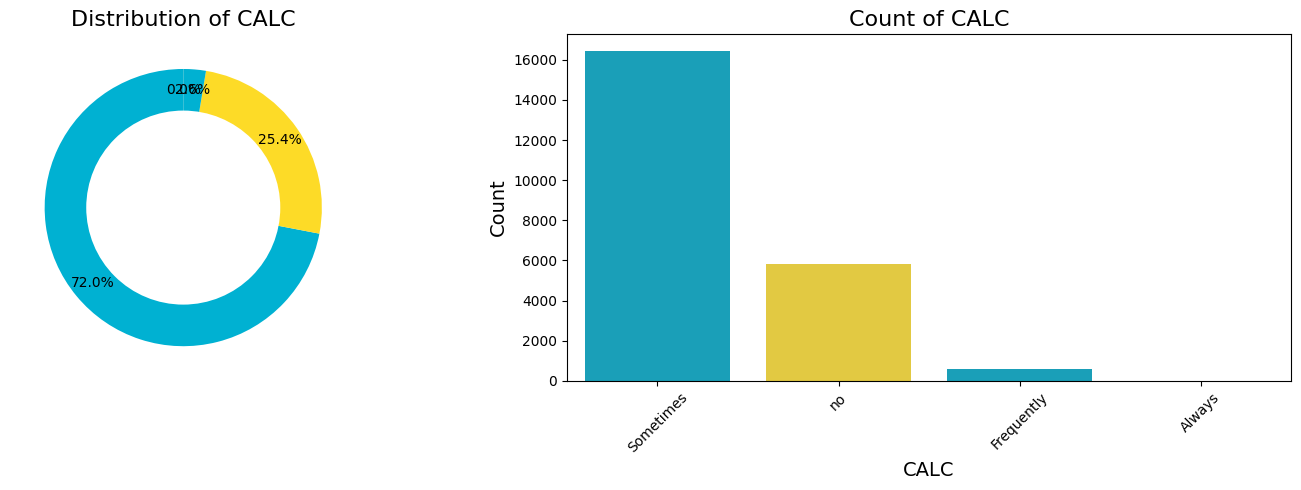

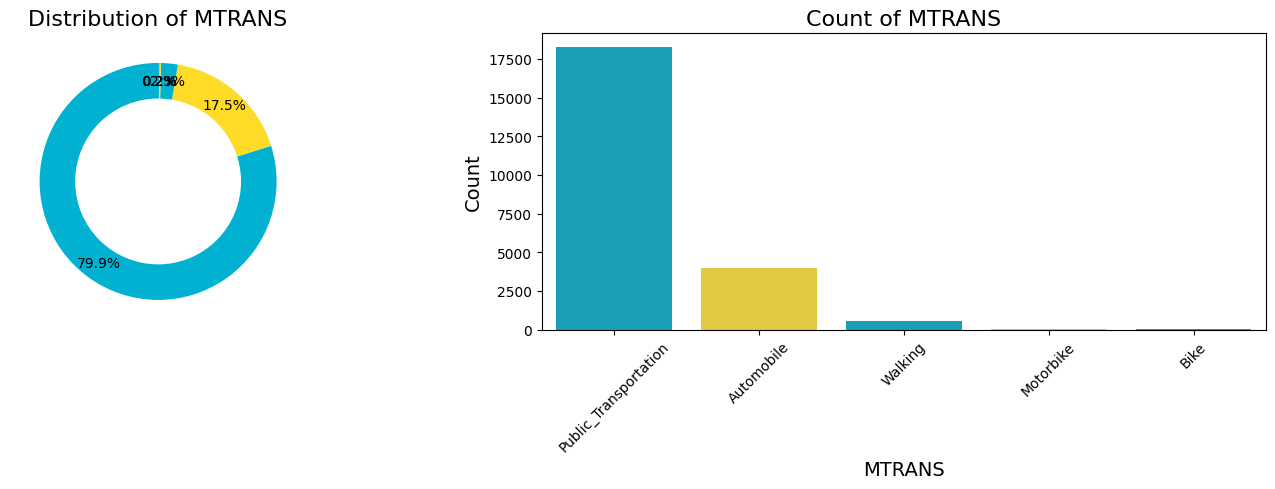

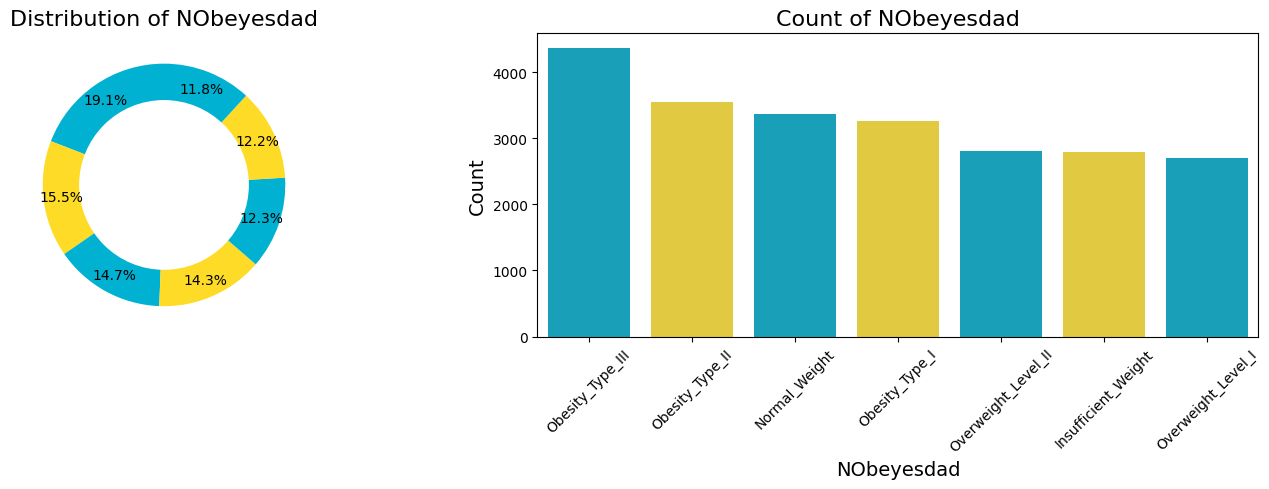

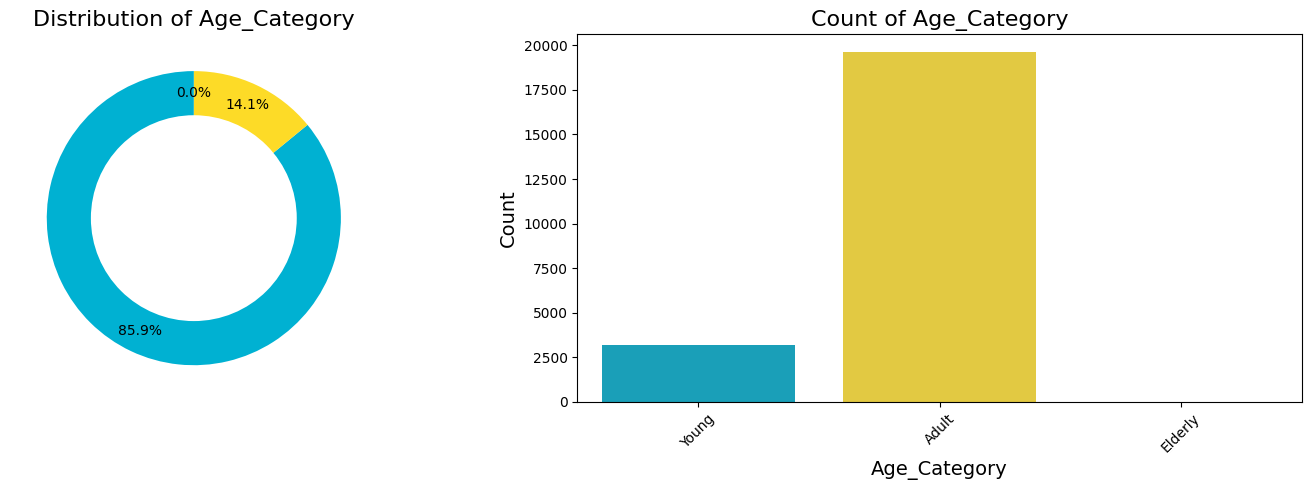

In [131]:
for i in cat_tr_d:
    single_plot_distribution(f'{i}',tr_d)


#### Bivariate analysis

#### Numerical data

In [132]:
# Scatter Plot to Show Realationship Bw 2 Cols
def advanced_scatter_plot(x_column, y_column, target_column, dataframe):
    plt.figure(figsize=(15, 6))
    sns.scatterplot(x=x_column, y=y_column, hue=target_column, data=dataframe, palette=palette[0:3])
    plt.title(f'Scatter Plot of {x_column} vs {y_column} Hue by {target_column}', fontsize=16)
    plt.xlabel(x_column, fontsize=14)
    plt.ylabel(y_column, fontsize=14)
    plt.legend(title=target_column)
    plt.grid(True)
   # plt.savefig(f'fig/scatter_{x_column}_{y_column}_{target_column}.png')
    plt.show()

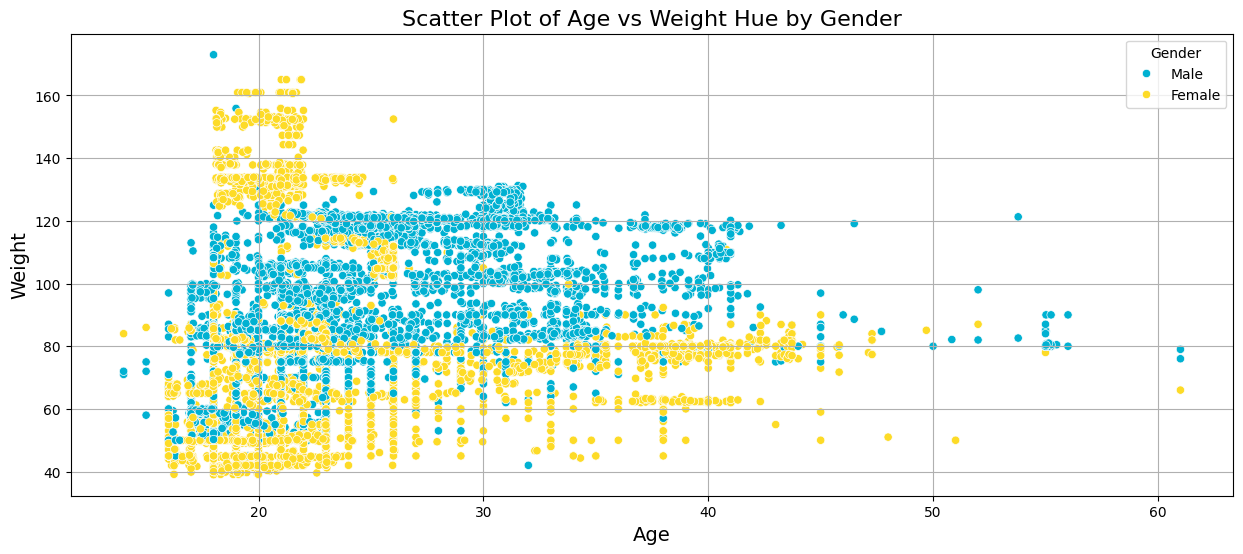

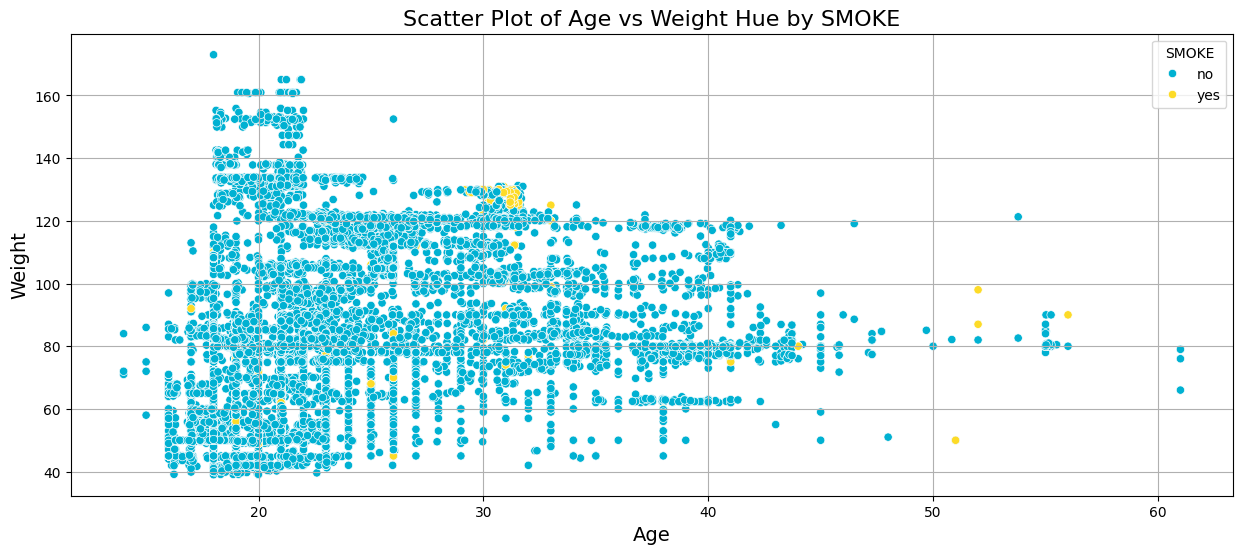

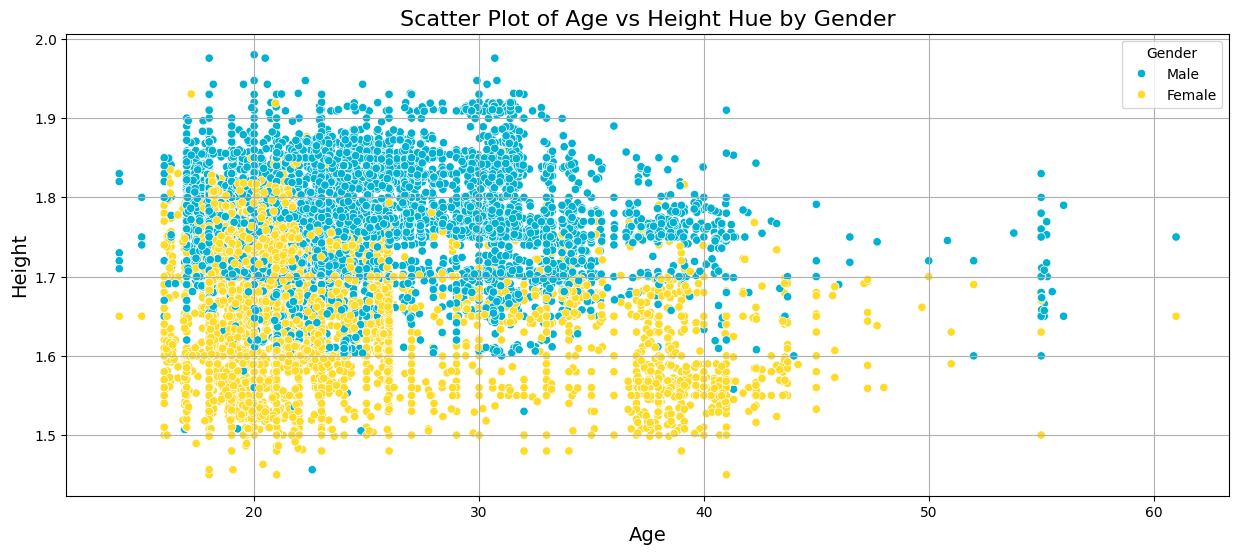

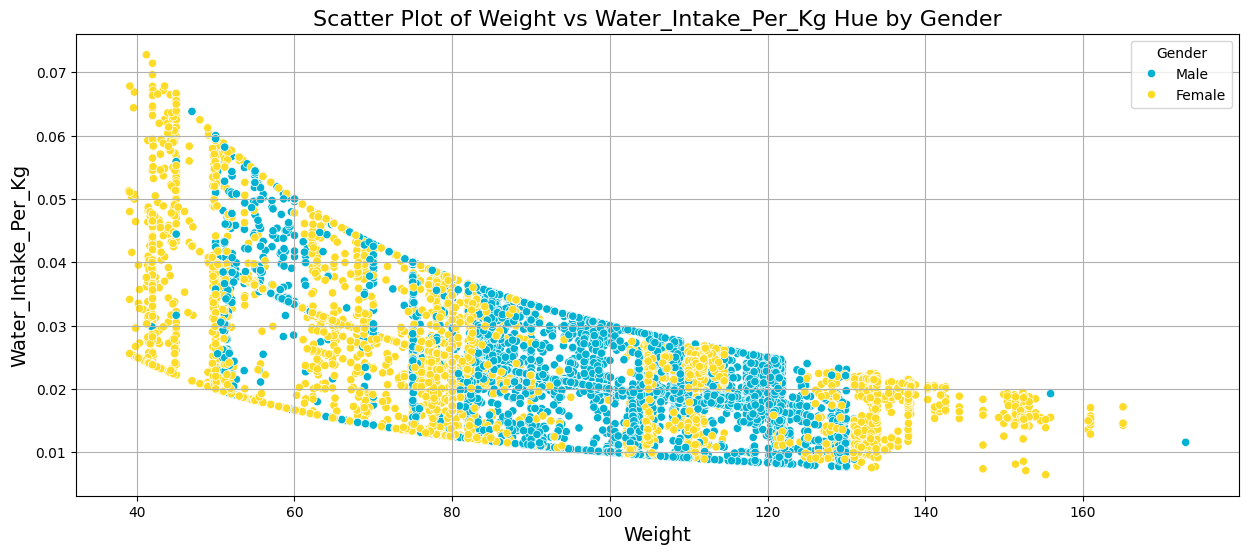

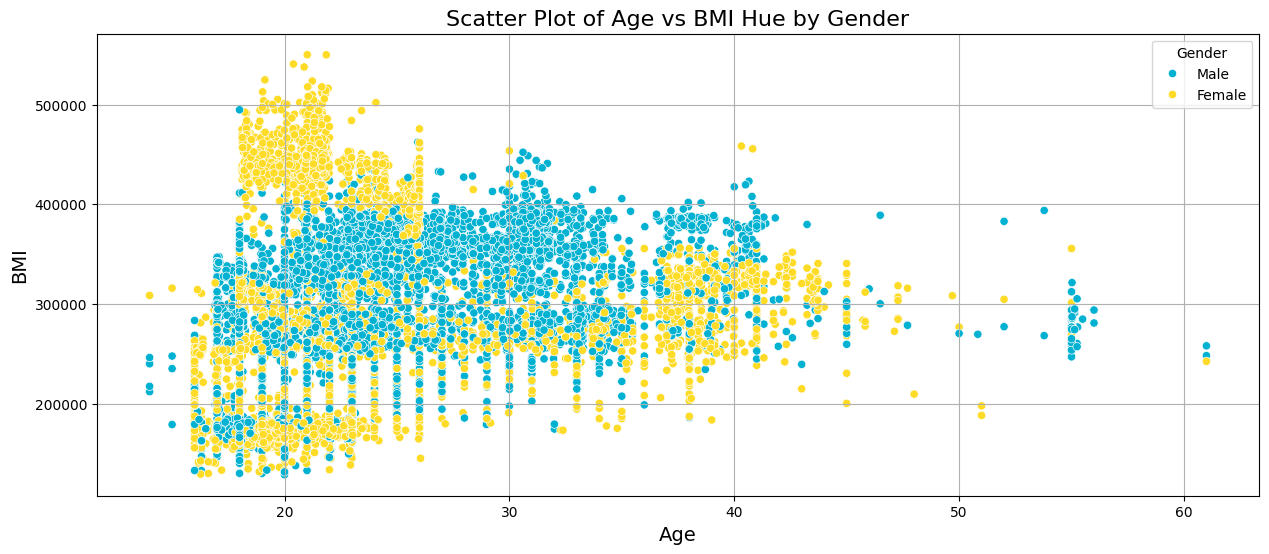

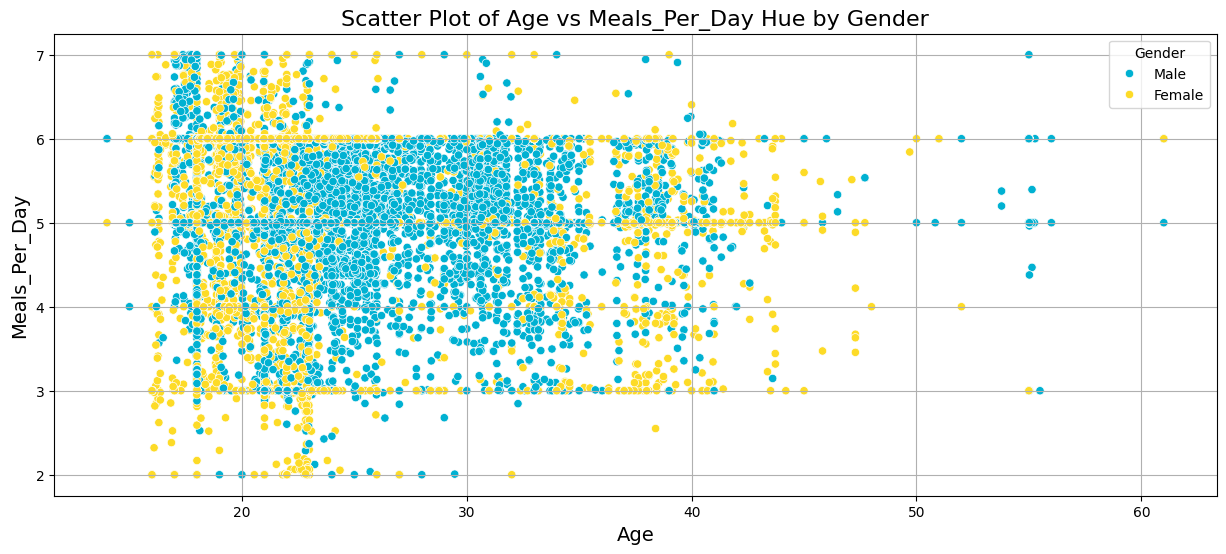

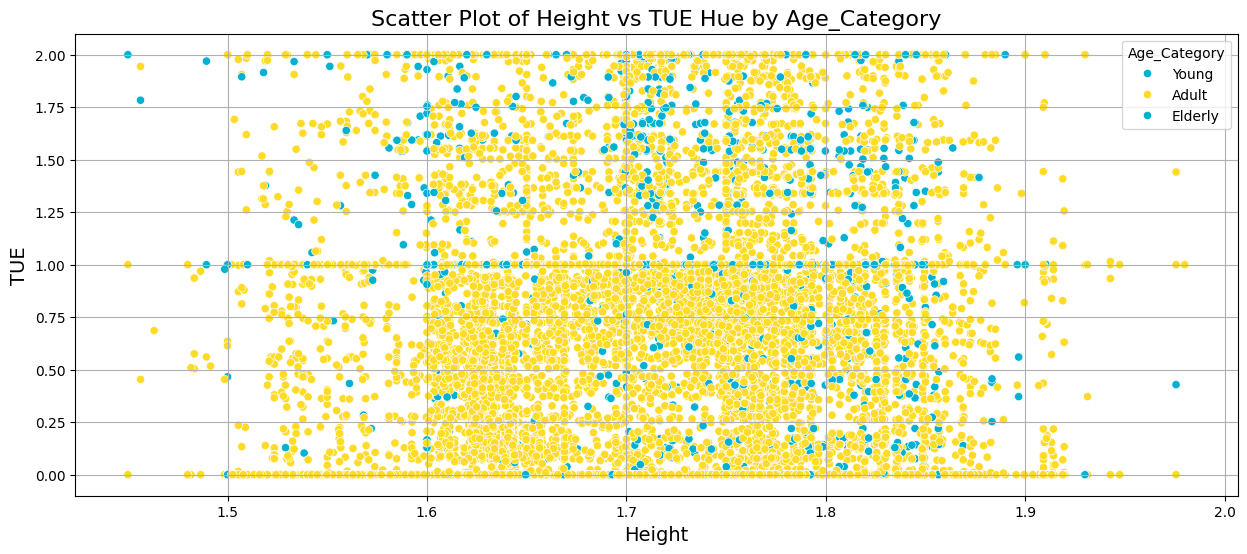

In [133]:
# Scatter Plot | to Show Age vs Weight RealtionShip
advanced_scatter_plot('Age', 'Weight', 'Gender', tr_d)
advanced_scatter_plot('Age', 'Weight', 'SMOKE', tr_d)
advanced_scatter_plot('Age', 'Height', 'Gender', tr_d)
advanced_scatter_plot('Weight', 'Water_Intake_Per_Kg', 'Gender', tr_d)
advanced_scatter_plot('Age', 'BMI', 'Gender', tr_d)
advanced_scatter_plot('Age', 'Meals_Per_Day', 'Gender', tr_d)
advanced_scatter_plot('Height', 'TUE', 'Age_Category', tr_d)

In [134]:
# Cols to Plot
columns_to_plot = ['Gender', 'Age', 'Height', 'Weight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'SCC', 'FAF',
       'CALC', 'MTRANS', 'NObeyesdad',
       'Age_Category', ]


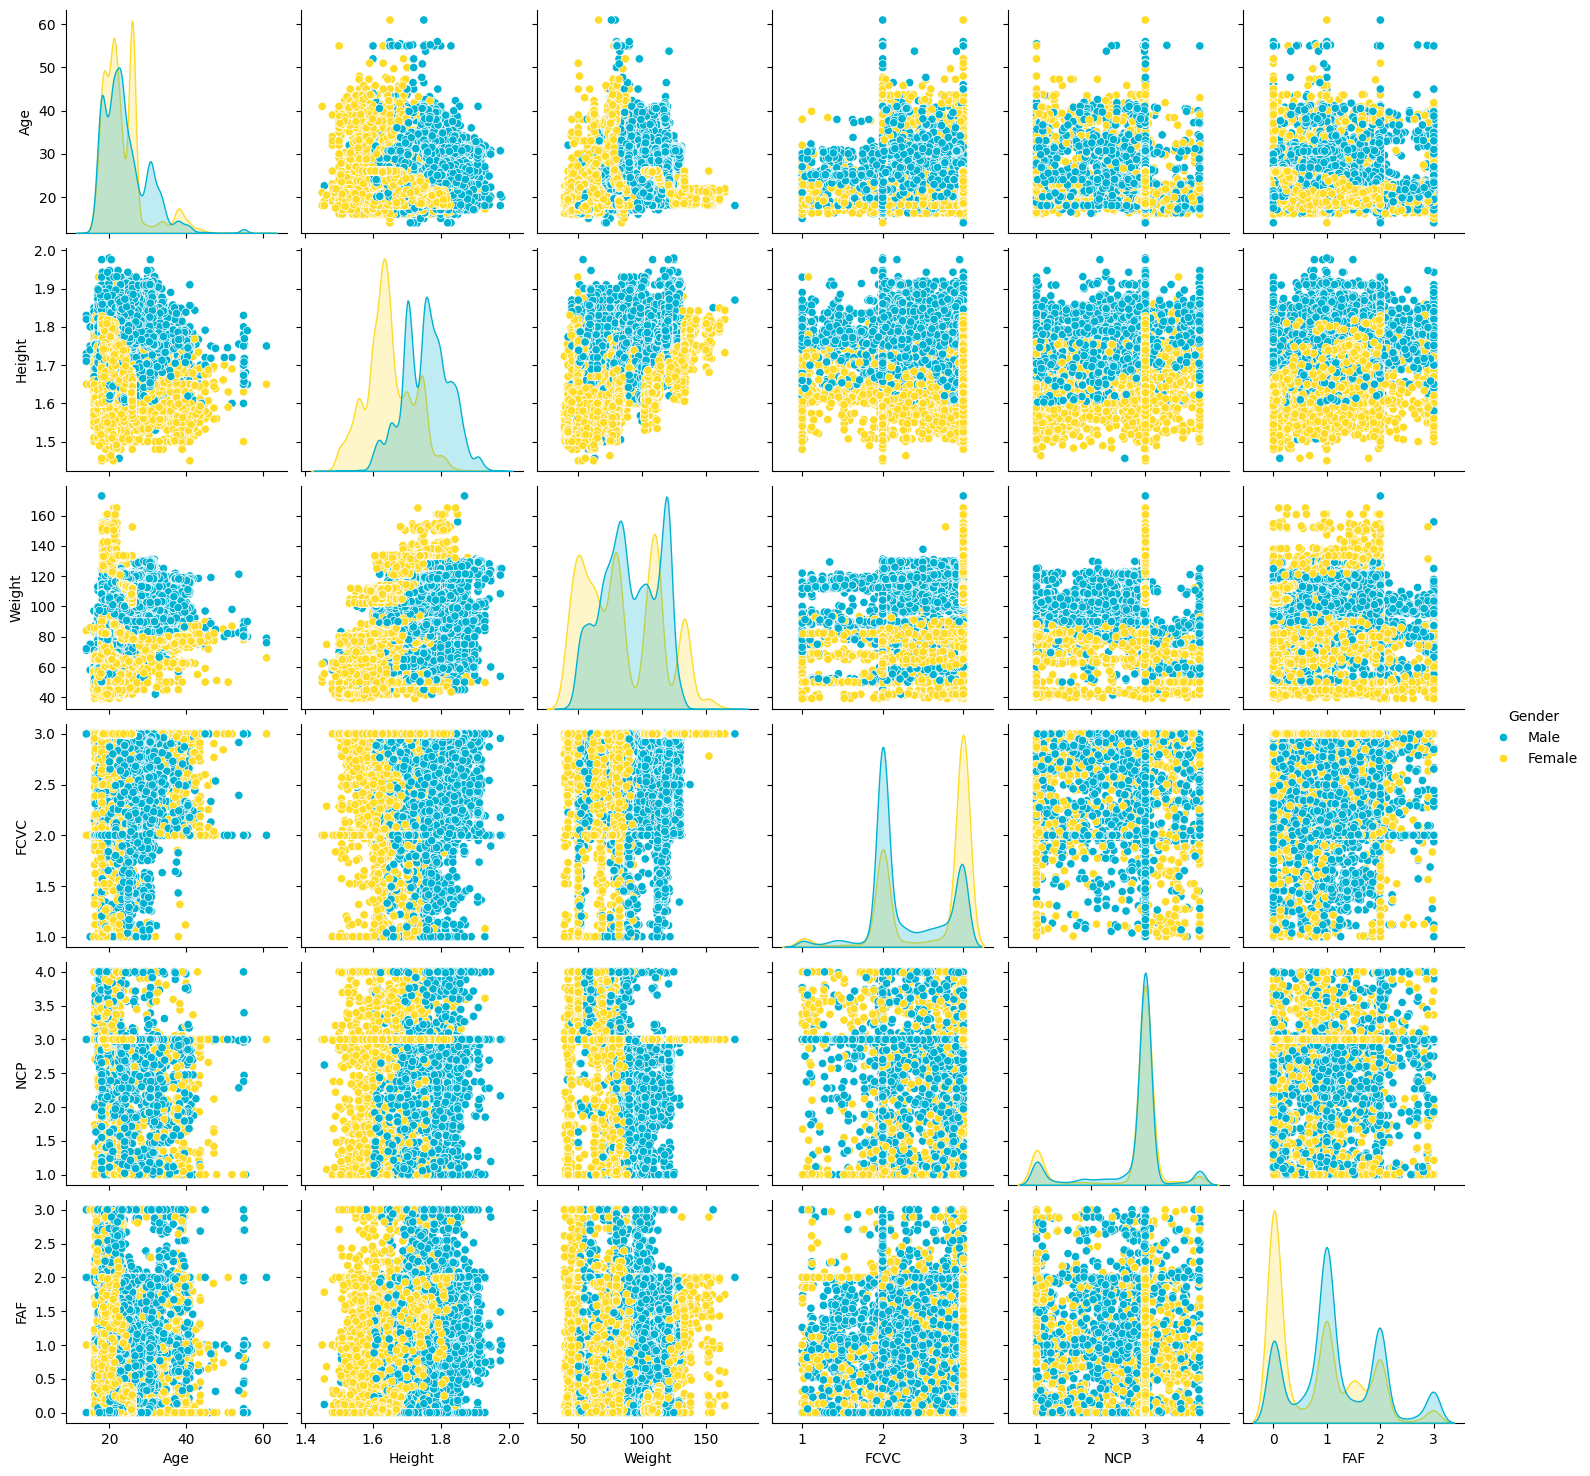

In [135]:

data_to_plot = tr_d[columns_to_plot]

Q_colors = {'Male': palette[0], 'Female': palette[1], 'other': 'gray'}

sns.pairplot(data_to_plot, hue='Gender', palette=Q_colors)
#plt.savefig('fig/pairplot.png')
plt.show()

## Step 6 | Outlier Detection




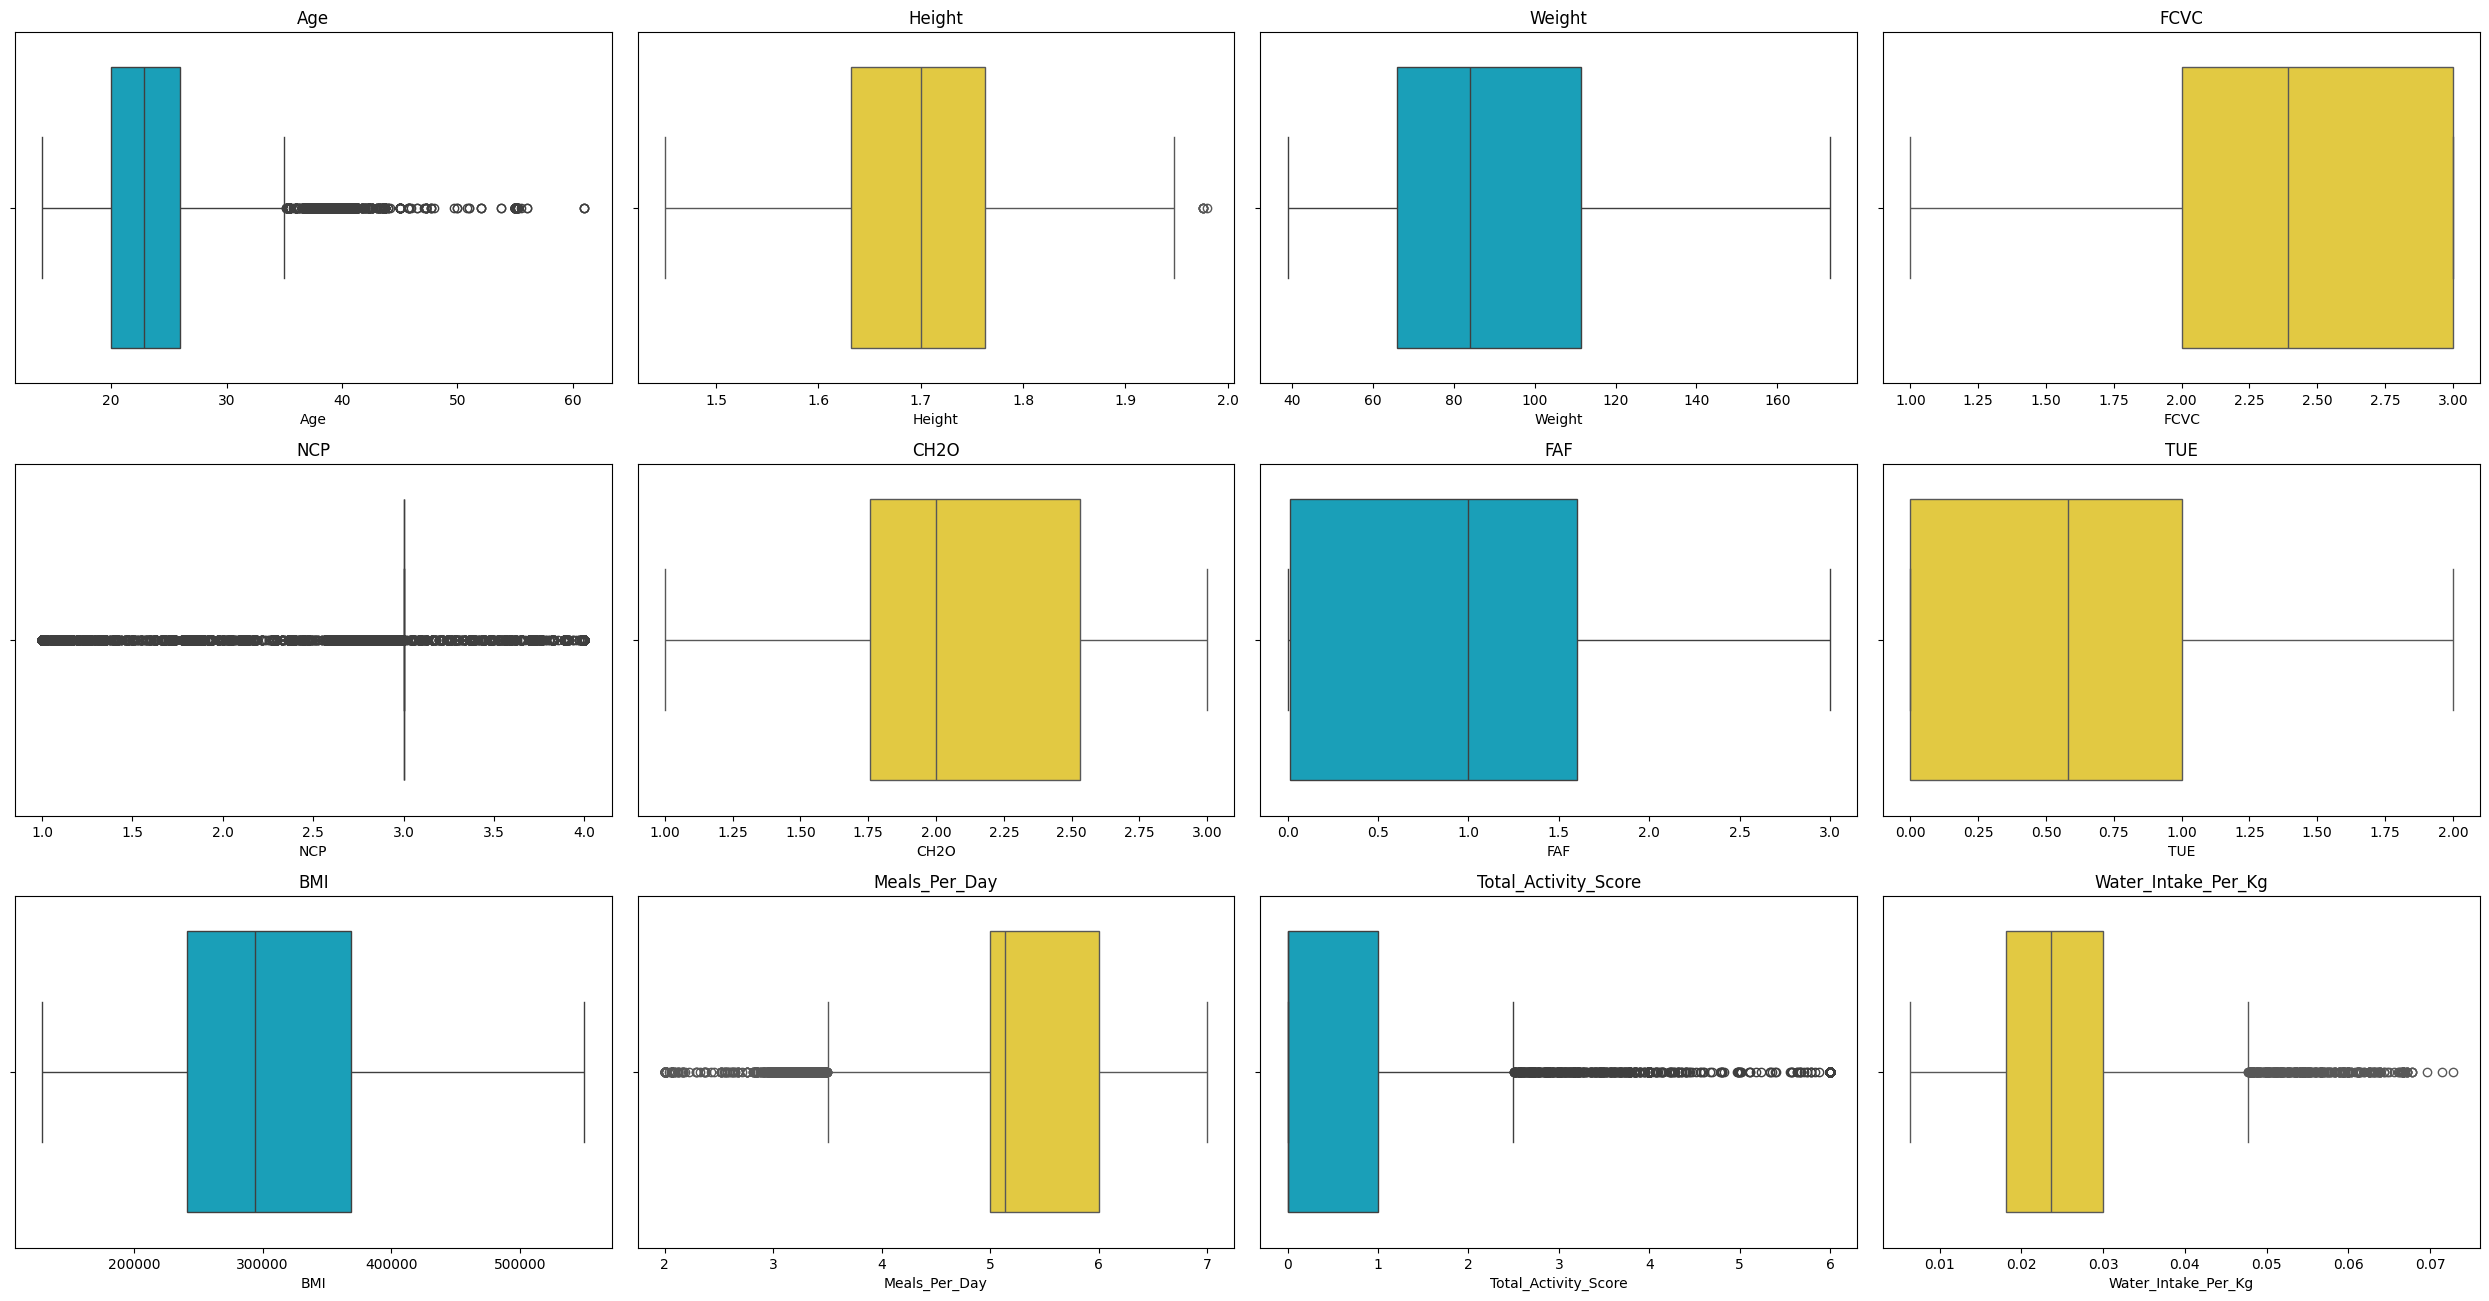

In [136]:

NUM_COLS_F = [col for col in tr_d.columns if tr_d[col].dtype == 'float']

# Define the number of rows and columns for subplots
num_rows = 4  # 4 rows
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 17))

palettes = ["rgb(0, 177, 210)", "rgb(253, 219, 39)"]

axes = axes.flatten()

for i, col in enumerate(NUM_COLS_F[:num_rows * num_cols]):
    sns.boxplot(x=tr_d[col], ax=axes[i], color=palette[i % len(palette)])
    axes[i].set_title(col)

# Hide empty subplots
for i in range(len(NUM_COLS_F), num_rows * num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
#plt.savefig('fig/boxplots_outliers.png')
plt.show()

## Numerical Feature Distribution and SKewness

In [137]:
# Function to Plot Numerical Distribution
def plot_numerical_distribution_with_hue(data, num_cols, hue_col='Gender', figsize=(25, 25), dpi=100):

    rows = (len(num_cols) + 1) // 2
    fig, ax = plt.subplots(rows, 2, figsize=figsize, dpi=dpi)
    ax = ax.flatten()
    for i, column in enumerate(num_cols):
        sns.histplot(data=data, x=column, hue=hue_col, ax=ax[i], kde=True, palette=palette)
        ax[i].set_title(f'{column} Distribution', size=14)
        ax[i].set_xlabel(None)
        ax[i].set_ylabel(None)

        # Calculate skewness
        skewness = skew(data[column].dropna())
        skew_label = f'Skewness: {skewness:.2f}'

        ax[i].annotate(skew_label, xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12, color='red')

    for j in range(len(num_cols), len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()
    #plt.savefig('fig/numerical_distributions.png')

    plt.show()

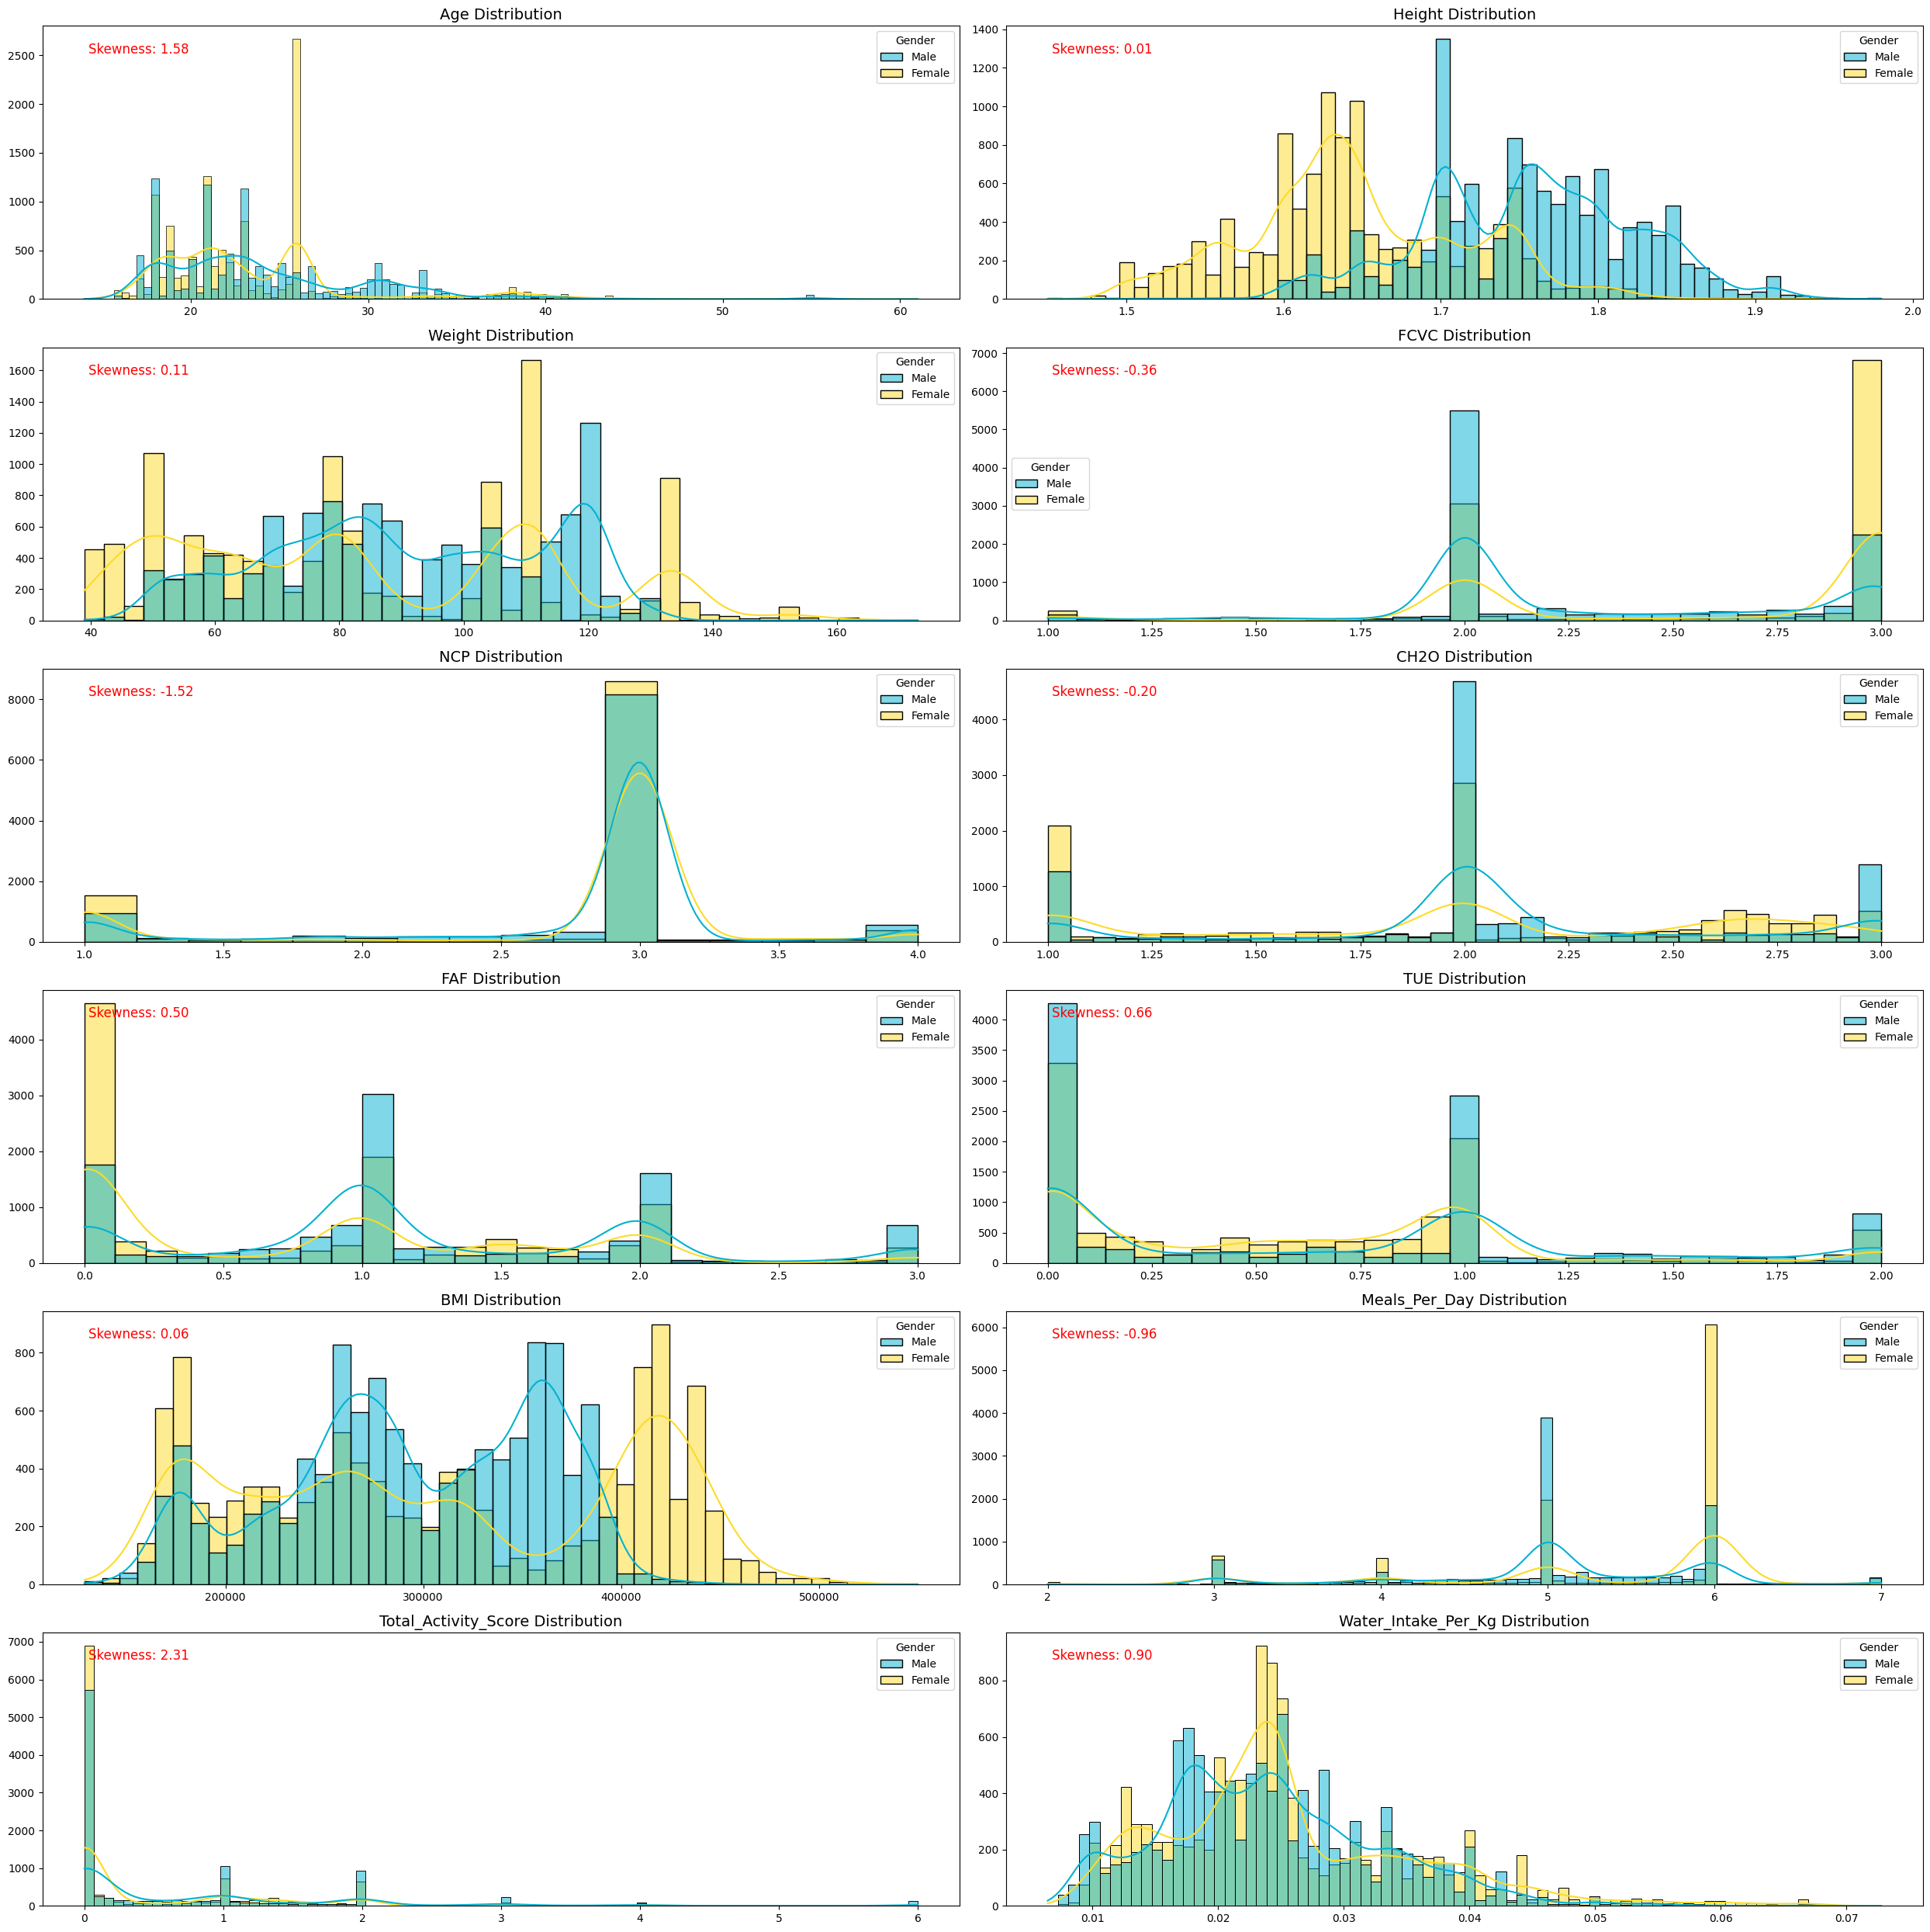

In [138]:
# Cols to Plot
plot_numerical_distribution_with_hue(tr_d,num_tr_d,'Gender')

In [139]:
skewness_num = skew(tr_d[num_tr_d])
skewness_series = pd.Series(skewness_num, index=num_tr_d)
skewness_series.sort_values(ascending=False)

,0
Total_Activity_Score,2.306555
Age,1.584001
Water_Intake_Per_Kg,0.896565
TUE,0.664513
FAF,0.504835
Weight,0.106599
BMI,0.064598
Height,0.012339
CH2O,-0.202751
FCVC,-0.364957


## Step 7.1 | Normalization

In [140]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer


X_train_features = tr_d.drop('NObeyesdad', axis=1)
y_train_target = tr_d['NObeyesdad'] # Keep the target column separate

columns_to_scale = [col for col in X_train_features.columns if X_train_features[col].dtype in ['float64', 'int64']]

scaler_type = 'Q'   # 'S' = StandardScaler, 'M' = MinMaxScaler, 'Q' = QuantileTransformer

# Select scaler
if scaler_type == 'S':
    scaler = StandardScaler()
elif scaler_type == 'M':
    scaler = MinMaxScaler()
elif scaler_type == 'Q':
    scaler = QuantileTransformer(output_distribution='normal', random_state=42)
else:
    raise ValueError("Invalid scaler type")

# ColumnTransformer configuration:


scaler_trf = ColumnTransformer(
    transformers=[('scaler', scaler, columns_to_scale)],
    remainder='passthrough'
)

X_train_scaled_array = scaler_trf.fit_transform(X_train_features)

te_d_scaled_array = scaler_trf.transform(te_d)

transformed_feature_names = []
transformed_feature_names.extend(columns_to_scale)
transformed_feature_names.extend([col for col in X_train_features.columns if col not in columns_to_scale])

tr_d_scaled_df = pd.DataFrame(X_train_scaled_array, columns=transformed_feature_names, index=X_train_features.index)
te_d_scaled_df = pd.DataFrame(te_d_scaled_array, columns=transformed_feature_names, index=te_d.index)


tr_d = pd.concat([tr_d_scaled_df, y_train_target], axis=1)

te_d = te_d_scaled_df

PrintColor('Data Scaled Done')


Data Scaled Done


## Step 8 | Correlation Analysis

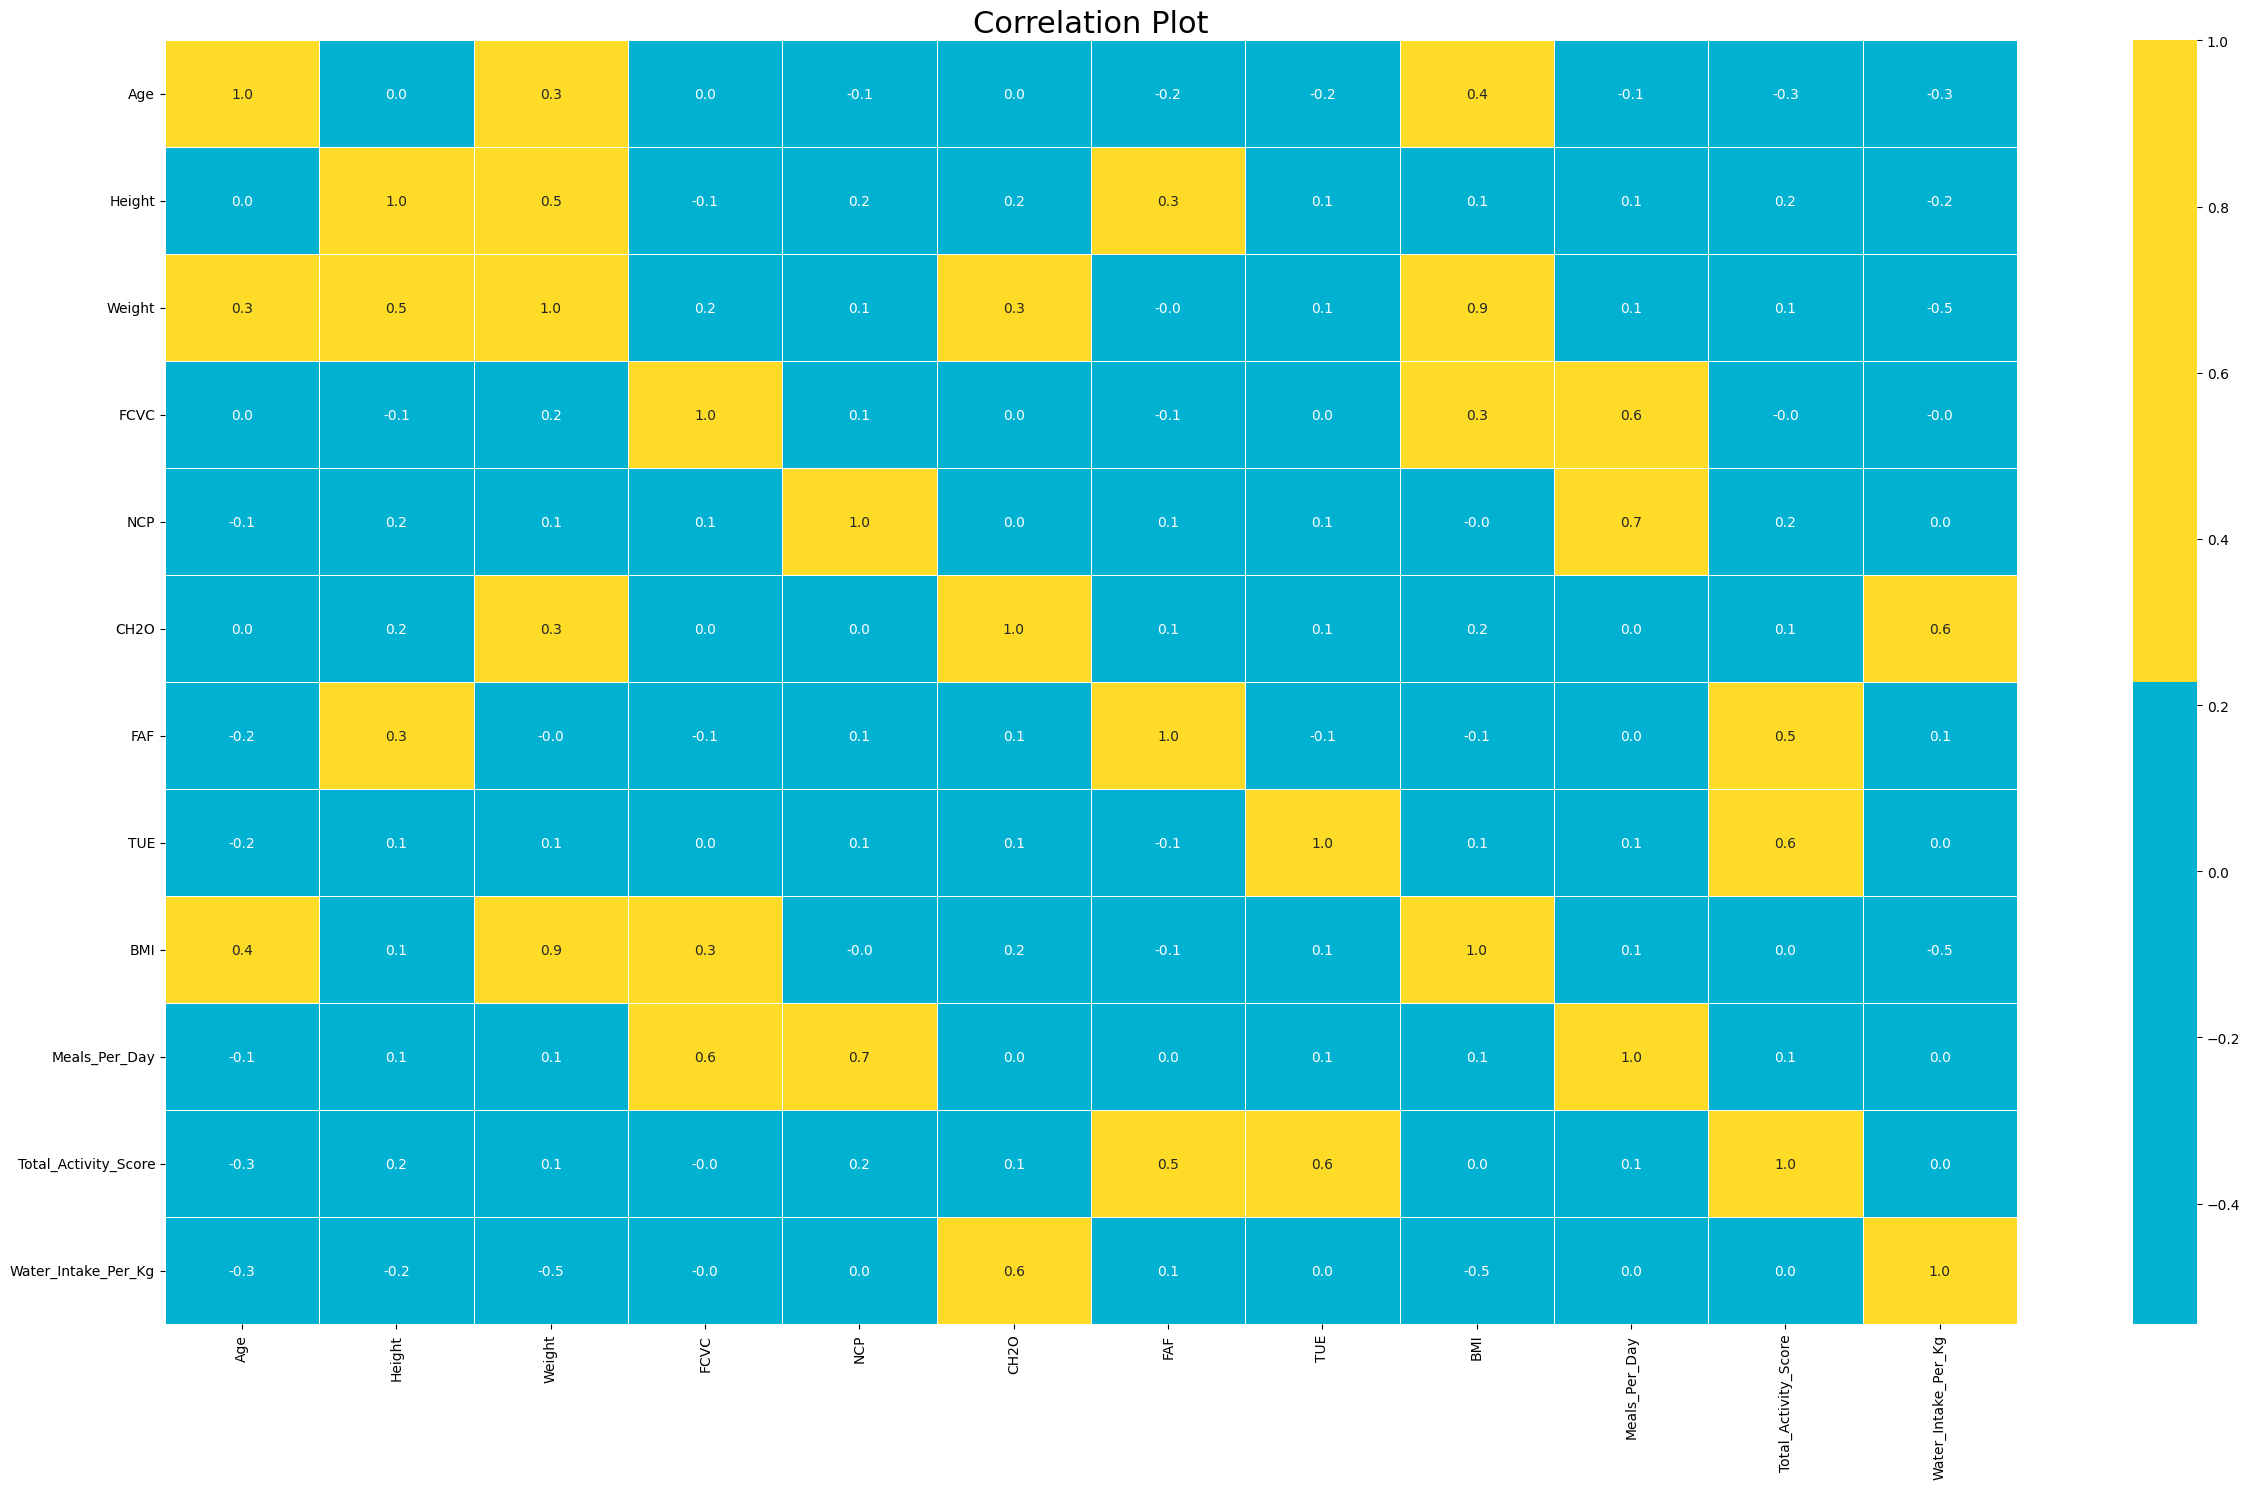

In [141]:

# Compute the correlation matrix
correlation_matrix = tr_d[num_tr_d].corr()


plt.figure(figsize=(25, 15))
sns.heatmap(correlation_matrix, annot=True, cmap=palette, fmt=".1f", linewidths=0.5)
plt.title('Correlation Plot', fontsize=22)
plt.tight_layout()
#plt.savefig('fig/correlation_heatmap.png')
plt.show()

## Step 9 | Encoding

In [142]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import pandas as pd

categorical_features_to_encode = [col for col in cat_tr_d if col != 'NObeyesdad']

method = 'D'   # 'L' = Label/Ordinal Encoding, 'D' = OneHot Encoding

if method == 'L':
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
elif method == 'D':
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
else:
    raise ValueError("Invalid method! Choose 'L' or 'D'.")

encoder_trf = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_features_to_encode)
    ],
    remainder='passthrough'
)

X_train_features_for_encoding = tr_d.drop('NObeyesdad', axis=1)
y_train_target_original = tr_d['NObeyesdad']

tr_d_enc_array = encoder_trf.fit_transform(X_train_features_for_encoding)
te_d_enc_array = encoder_trf.transform(te_d)

if method == 'D':
    encoded_cat_cols_names = encoder_trf.named_transformers_['cat'].get_feature_names_out(categorical_features_to_encode)
else:
    encoded_cat_cols_names = categorical_features_to_encode # For OrdinalEncoder, names are same

passthrough_cols_names = [col for col in X_train_features_for_encoding.columns if col not in categorical_features_to_encode]

final_feature_columns = list(encoded_cat_cols_names) + passthrough_cols_names

tr_d = pd.DataFrame(tr_d_enc_array, columns=final_feature_columns, index=tr_d.index)
te_d = pd.DataFrame(te_d_enc_array, columns=final_feature_columns, index=te_d.index)

# Ensure all feature columns are numeric after encoding and dataframe reconstruction
for col in tr_d.columns:
    tr_d[col] = pd.to_numeric(tr_d[col], errors='coerce')

for col in te_d.columns:
    te_d[col] = pd.to_numeric(te_d[col], errors='coerce')

tr_d['NObeyesdad'] = y_train_target_original

PrintColor('Categorical Encoding Done')


Categorical Encoding Done


## Step 10 | Model Building

In [143]:
X_T = tr_d.drop('NObeyesdad', axis=1)
y_T = tr_d['NObeyesdad']

X_TR, X_TE, Y_TR, Y_TE = train_test_split(X_T, y_T, test_size=0.1, random_state=42)

PrintColor(f"Training set shape - X: {X_TR.shape}, y: {Y_TR.shape}")
PrintColor(f"Testing set shape - X: {X_TE.shape}, y: {Y_TE.shape}")

Training set shape - X: (20560, 38), y: (20560,)
Testing set shape - X: (2285, 38), y: (2285,)


In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier # Corrected import
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier # Added for LightGBM
from catboost import CatBoostClassifier # Added for CatBoost

PrintColor('Imported necessary libraries for simple models.', Fore.GREEN)

Imported necessary libraries for simple models.


In [145]:
from sklearn.pipeline import Pipeline

# Existing parameters for LightGBM (from QJasqK8lW2jY)
lgb_params = {
 'n_estimators': 899,
 'learning_rate': 0.013003893032117776,
 'max_depth': 18,
 'reg_alpha': 0.9218377389528793,
 'reg_lambda': 0.020694654173173645,
 'num_leaves': 24,
 'subsample': 0.7402011916024158,
 'colsample_bytree': 0.25484261764678784,
 'verbose' : -1
}

# Existing parameters for CatBoost (from 0x-S7SzxW2jZ)
cat_params = {
    'n_estimators': 853,
    'learning_rate': 0.10899577626375372,
    'depth': 7,
    'colsample_bylevel': 0.7340962061535496,
    'random_strength': 6.262882561405091,
    'min_data_in_leaf': 92,
    'verbose': 0,
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
}

# 1. Initialize Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Initialize Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)

# 3. Initialize Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# 4. Initialize K-Nearest Neighbors Classifier
k_neighbors_model = KNeighborsClassifier()

# 5. Initialize LightGBM Classifier
# Note: CatBoost handles one-hot encoded features as numerical, so no need to specify cat_features here
lightgbm_model = LGBMClassifier(**lgb_params)

# 6. Initialize CatBoost Classifier
# As features are already one-hot encoded, treat all as numerical
catboost_model = CatBoostClassifier(**cat_params, cat_features=[])

# 7. Create pipelines for each model
models = {
    'Logistic Regression': Pipeline([('classifier', logistic_regression_model)]),
    'Random Forest': Pipeline([('classifier', random_forest_model)]),
    'Decision Tree': Pipeline([('classifier', decision_tree_model)]),
    'K-Nearest Neighbors': Pipeline([('classifier', k_neighbors_model)]),
    'LightGBM': Pipeline([('classifier', lightgbm_model)]),
    'CatBoost': Pipeline([('classifier', catboost_model)])
}

PrintColor('Initialized models and created pipelines.', Fore.GREEN)

Initialized models and created pipelines.


In [146]:
for name, pipeline in models.items():
    print_boxed_blue_heading(f"Training {name}...")
    pipeline.fit(X_TR, Y_TR)
    accuracy = pipeline.score(X_TE, Y_TE)
    PrintColor(f"{name} Initial Accuracy: {accuracy:.4f}", Fore.MAGENTA)



| Training Logistic Regression... |
Logistic Regression Initial Accuracy: 0.8670

| Training Random Forest... |
Random Forest Initial Accuracy: 0.9068

| Training Decision Tree... |
Decision Tree Initial Accuracy: 0.8486

| Training K-Nearest Neighbors... |
K-Nearest Neighbors Initial Accuracy: 0.7829

| Training LightGBM... |
LightGBM Initial Accuracy: 0.9164

| Training CatBoost... |
CatBoost Initial Accuracy: 0.9072


In [147]:
for name, pipeline in models.items():
    print_boxed_blue_heading(f"Performing 5-fold cross-validation for {name}...")
    cv_scores = cross_val_score(pipeline, X_T, y_T, cv=5, scoring='accuracy', n_jobs=-1)
    PrintColor(f"{name} Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})", Fore.BLUE)



| Performing 5-fold cross-validation for Logistic Regression... |
Logistic Regression Cross-Validation Accuracy: 0.8722 (+/- 0.0093)

| Performing 5-fold cross-validation for Random Forest... |
Random Forest Cross-Validation Accuracy: 0.9060 (+/- 0.0132)

| Performing 5-fold cross-validation for Decision Tree... |
Decision Tree Cross-Validation Accuracy: 0.8471 (+/- 0.0106)

| Performing 5-fold cross-validation for K-Nearest Neighbors... |
K-Nearest Neighbors Cross-Validation Accuracy: 0.7828 (+/- 0.0117)

| Performing 5-fold cross-validation for LightGBM... |
LightGBM Cross-Validation Accuracy: 0.9146 (+/- 0.0111)

| Performing 5-fold cross-validation for CatBoost... |
CatBoost Cross-Validation Accuracy: 0.9100 (+/- 0.0114)



| Evaluating Logistic Regression: |


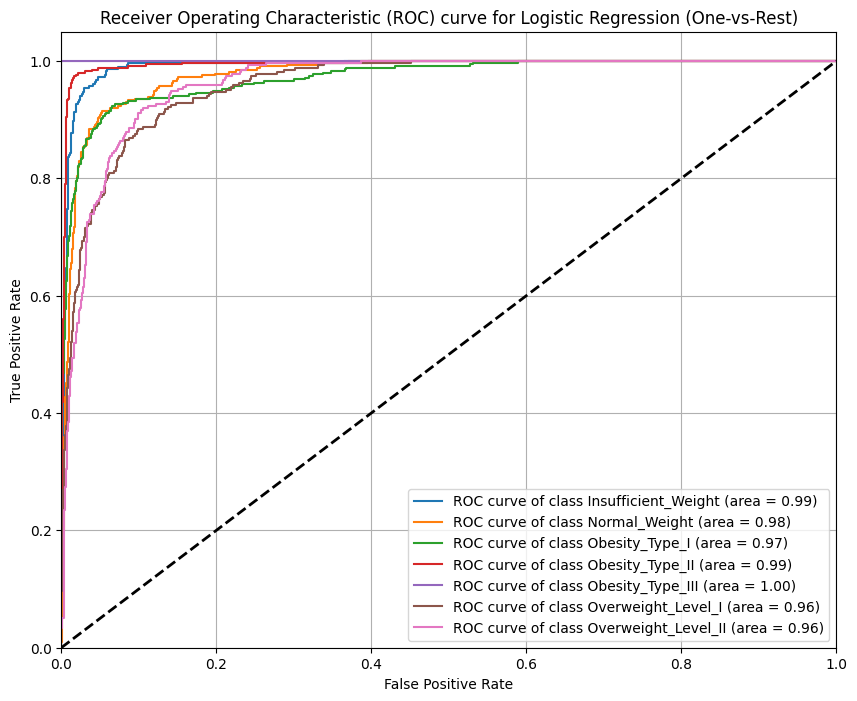

<Figure size 1000x800 with 0 Axes>

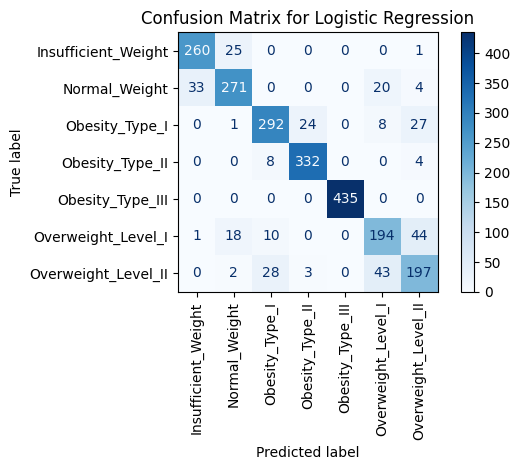


| Evaluating Random Forest: |


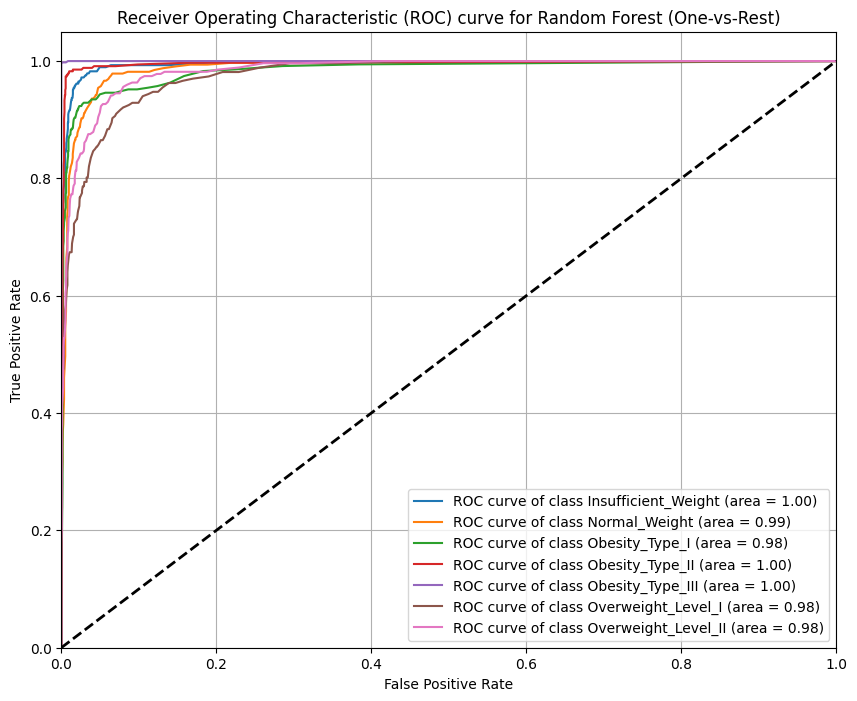

<Figure size 1000x800 with 0 Axes>

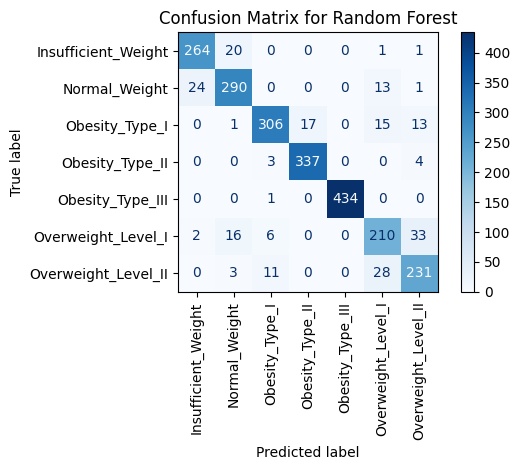


| Evaluating Decision Tree: |


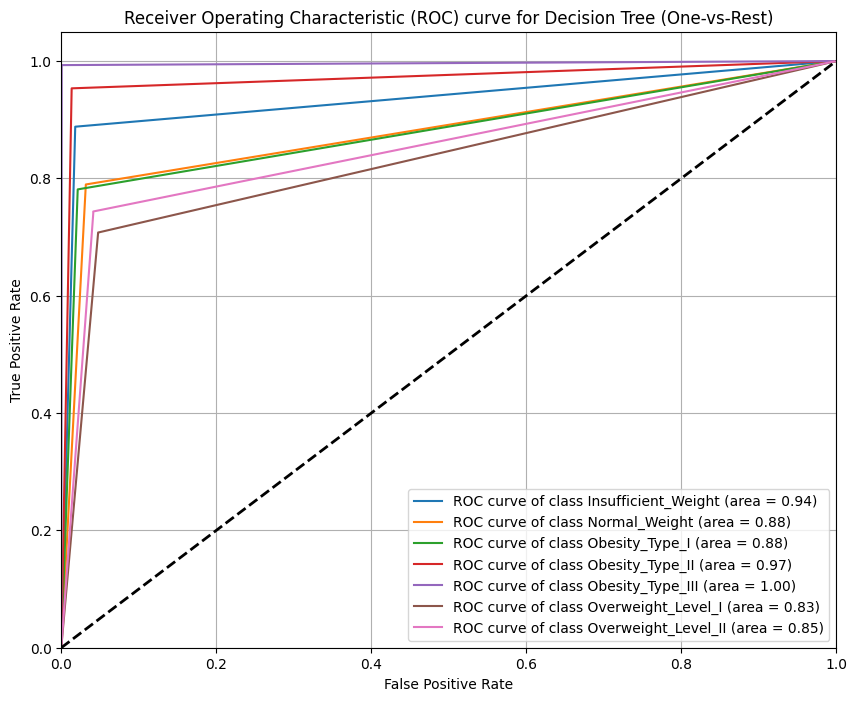

<Figure size 1000x800 with 0 Axes>

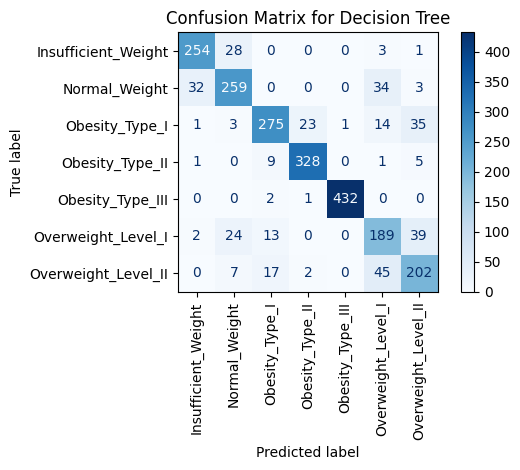


| Evaluating K-Nearest Neighbors: |


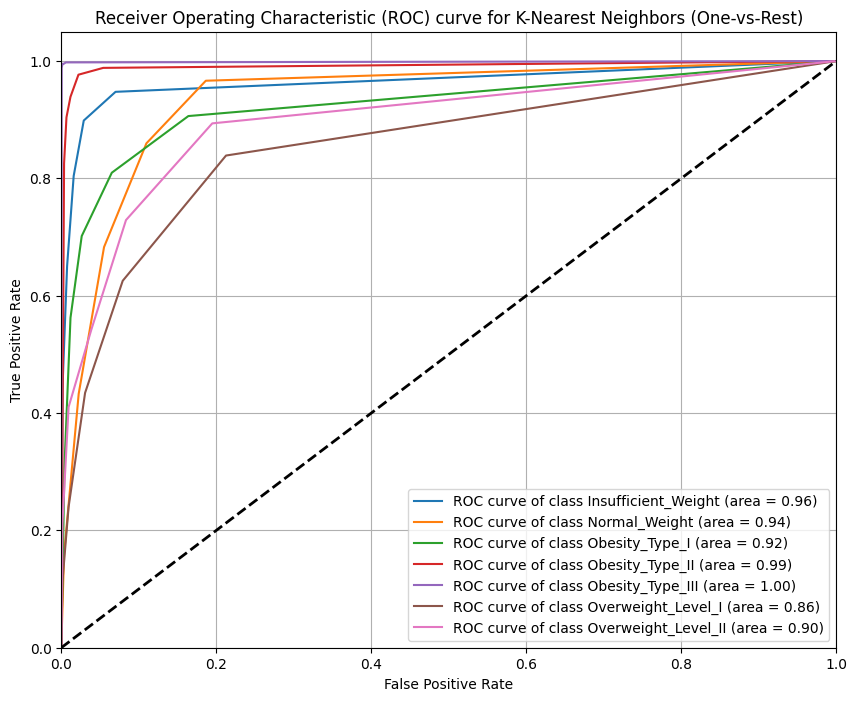

<Figure size 1000x800 with 0 Axes>

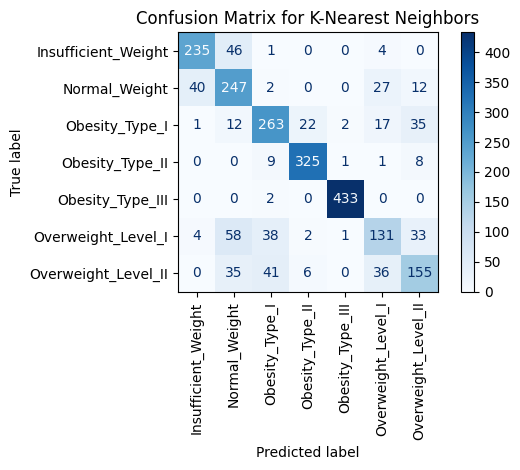


| Evaluating LightGBM: |


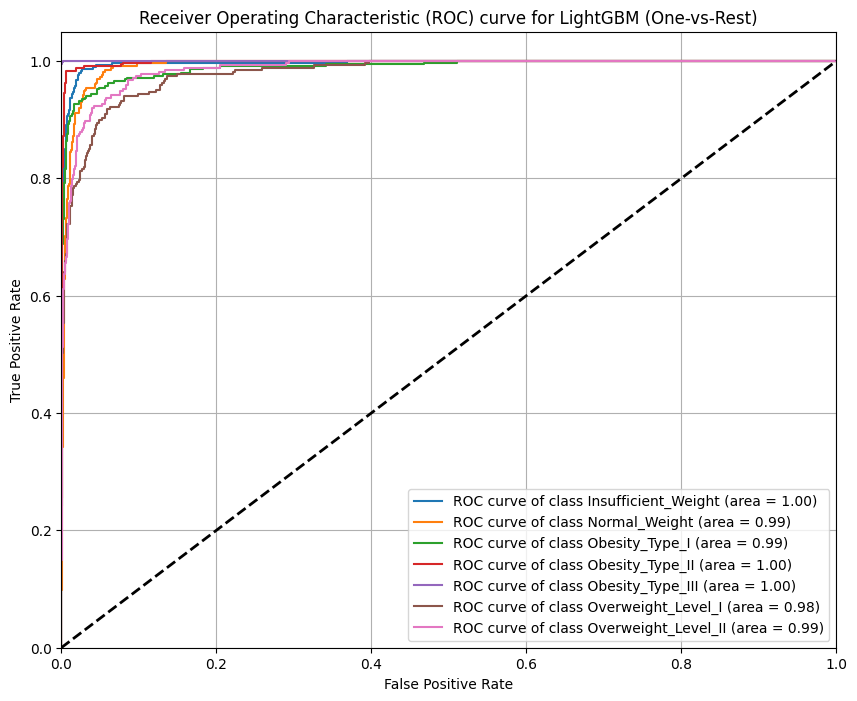

<Figure size 1000x800 with 0 Axes>

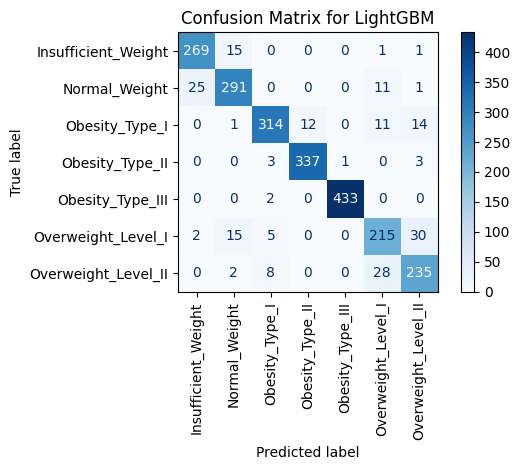


| Evaluating CatBoost: |


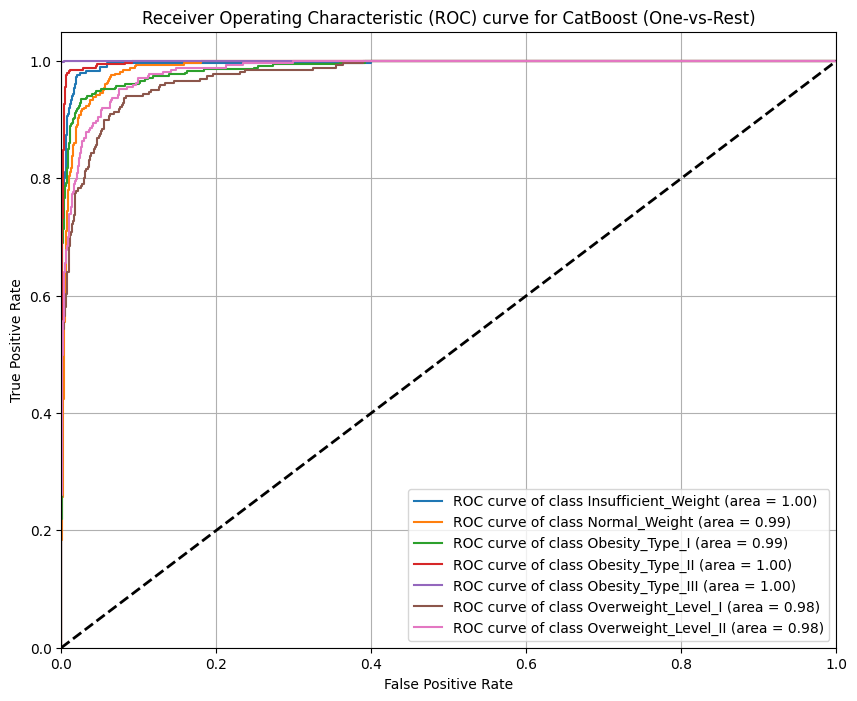

<Figure size 1000x800 with 0 Axes>

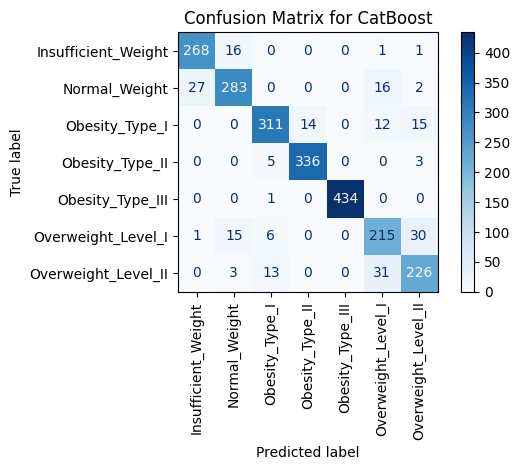

In [148]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelBinarizer

# Get unique classes to ensure consistent plotting order
unique_classes = sorted(Y_TE.unique())

for name, pipeline in models.items():
    print_boxed_blue_heading(f"Evaluating {name}:")

    # --- ROC AUC Curve ---
    if hasattr(pipeline, 'predict_proba'):
        y_score = pipeline.predict_proba(X_TE)

        # Binarize the true labels for ROC AUC calculation
        lb = LabelBinarizer()
        lb.fit(unique_classes)
        y_test_binarized = lb.transform(Y_TE)

        plt.figure(figsize=(10, 8))
        for i, class_name in enumerate(unique_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'ROC curve of class {class_name} (area = {roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random guess line
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic (ROC) curve for {name} (One-vs-Rest)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    else:
        print(f"{name} does not have predict_proba method for ROC AUC curve.")

    # --- Confusion Matrix ---
    y_pred = pipeline.predict(X_TE)
    cm = confusion_matrix(Y_TE, y_pred, labels=unique_classes)
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title(f'Confusion Matrix for {name}')
    plt.tight_layout()
    plt.show()


In [149]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

all_models_metrics = []

for name, pipeline in models.items():
    y_pred = pipeline.predict(X_TE)
    print_boxed_blue_heading(f"Classification Report for {name}:")
    print(classification_report(Y_TE, y_pred))


    accuracy = accuracy_score(Y_TE, y_pred)
    precision = precision_score(Y_TE, y_pred, average='weighted', zero_division=0)
    recall = recall_score(Y_TE, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(Y_TE, y_pred, average='weighted', zero_division=0)

    all_models_metrics.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

metrics_df = pd.DataFrame(all_models_metrics)
display(metrics_df)



| Classification Report for Logistic Regression: |
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.91      0.90       286
      Normal_Weight       0.85      0.83      0.84       328
     Obesity_Type_I       0.86      0.83      0.85       352
    Obesity_Type_II       0.92      0.97      0.94       344
   Obesity_Type_III       1.00      1.00      1.00       435
 Overweight_Level_I       0.73      0.73      0.73       267
Overweight_Level_II       0.71      0.72      0.72       273

           accuracy                           0.87      2285
          macro avg       0.85      0.85      0.85      2285
       weighted avg       0.87      0.87      0.87      2285


| Classification Report for Random Forest: |
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.92      0.92       286
      Normal_Weight       0.88      0.88      0.88       328
     Obesity_Type_I       0.94      0.87    

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.866958,0.866596,0.866958,0.866596
1,Random Forest,0.906783,0.907358,0.906783,0.906813
2,Decision Tree,0.848578,0.850828,0.848578,0.849150
3,K-Nearest Neighbors,0.782932,0.781467,0.782932,0.780274
4,LightGBM,0.916411,0.916979,0.916411,0.916487
5,CatBoost,0.907221,0.907789,0.907221,0.907322


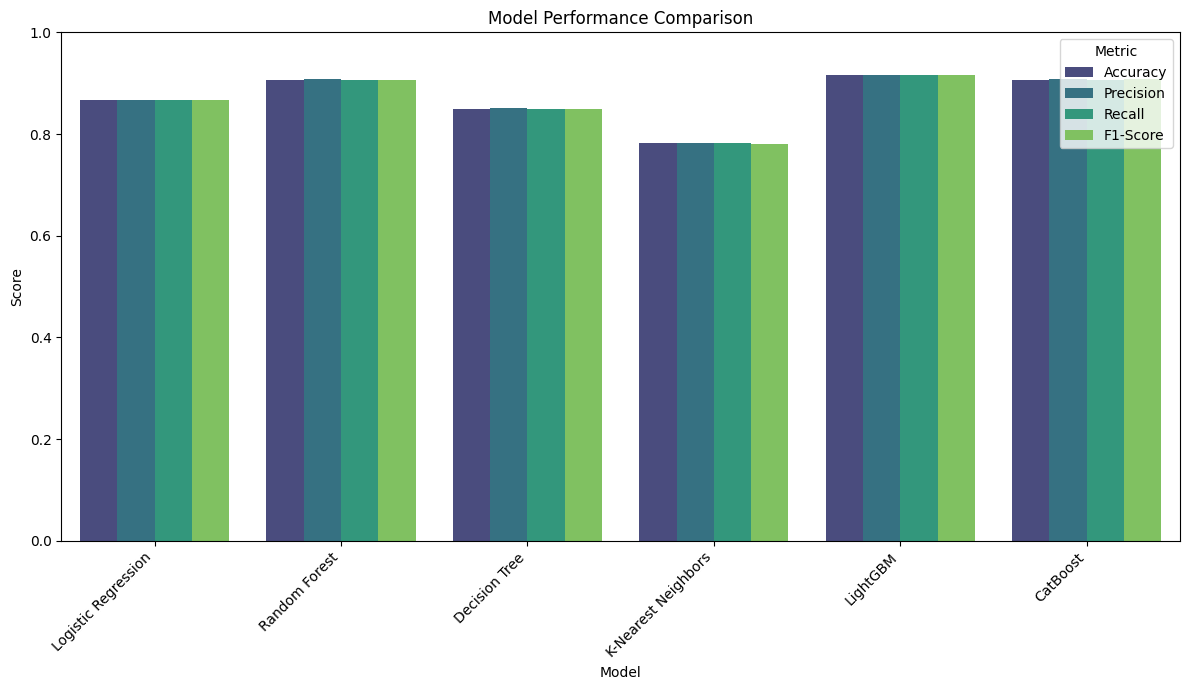

In [150]:
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import joblib
import os

output_dir = 'streamlit_assets'
os.makedirs(output_dir, exist_ok=True)

# --- 1. Save the best model (LightGBM pipeline) ---
best_model_pipeline = models['LightGBM']
joblib.dump(best_model_pipeline, os.path.join(output_dir, 'best_model_pipeline.pkl'))
PrintColor('Best model pipeline saved as best_model_pipeline.pkl', Fore.GREEN)

# --- 2. Save the numerical scaler ---
joblib.dump(scaler_trf.named_transformers_['scaler'], os.path.join(output_dir, 'scaler.pkl'))
PrintColor('Scaler saved as scaler.pkl', Fore.GREEN)

# --- 3. Save the categorical encoder ---
joblib.dump(encoder_trf.named_transformers_['cat'], os.path.join(output_dir, 'encoder.pkl'))
PrintColor('Encoder saved as encoder.pkl', Fore.GREEN)

# --- 4. Save the unique target classes ---
joblib.dump(unique_classes, os.path.join(output_dir, 'unique_classes.pkl'))
PrintColor('Unique target classes saved as unique_classes.pkl', Fore.GREEN)

Best model pipeline saved as best_model_pipeline.pkl
Scaler transformer saved as scaler_transformer.pkl
Encoder transformer saved as encoder_transformer.pkl
Unique target classes saved as unique_classes.pkl


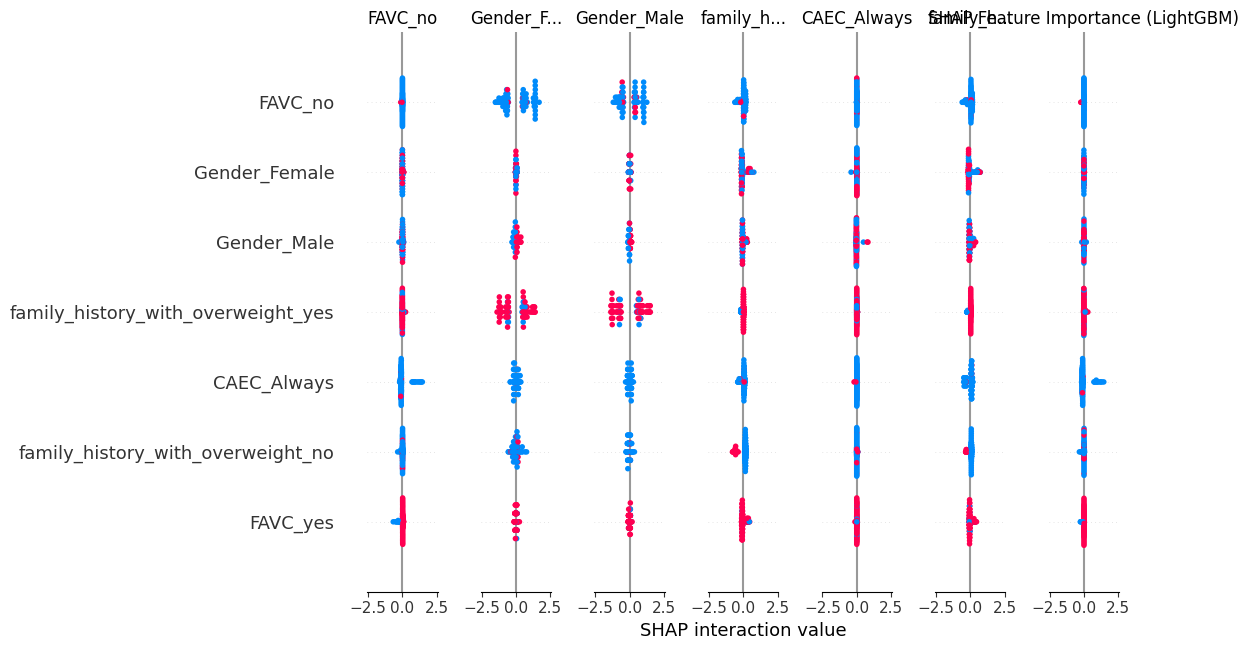

In [153]:

# !pip install shap

import shap

lightgbm_classifier = models['LightGBM'].named_steps['classifier']


explainer = shap.TreeExplainer(lightgbm_classifier)

shap_values = explainer.shap_values(X_TR.iloc[:100])

if isinstance(shap_values, list):
    abs_shap_values = np.abs(np.array(shap_values)).mean(axis=0)
    dummy_explainer = shap.TreeExplainer(lightgbm_classifier)
    dummy_explainer.expected_value = np.zeros(abs_shap_values.shape[0]) # Placeholder
    shap.summary_plot(abs_shap_values, X_TR.iloc[:100], plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_TR.iloc[:100], show=False)

plt.title('SHAP Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()


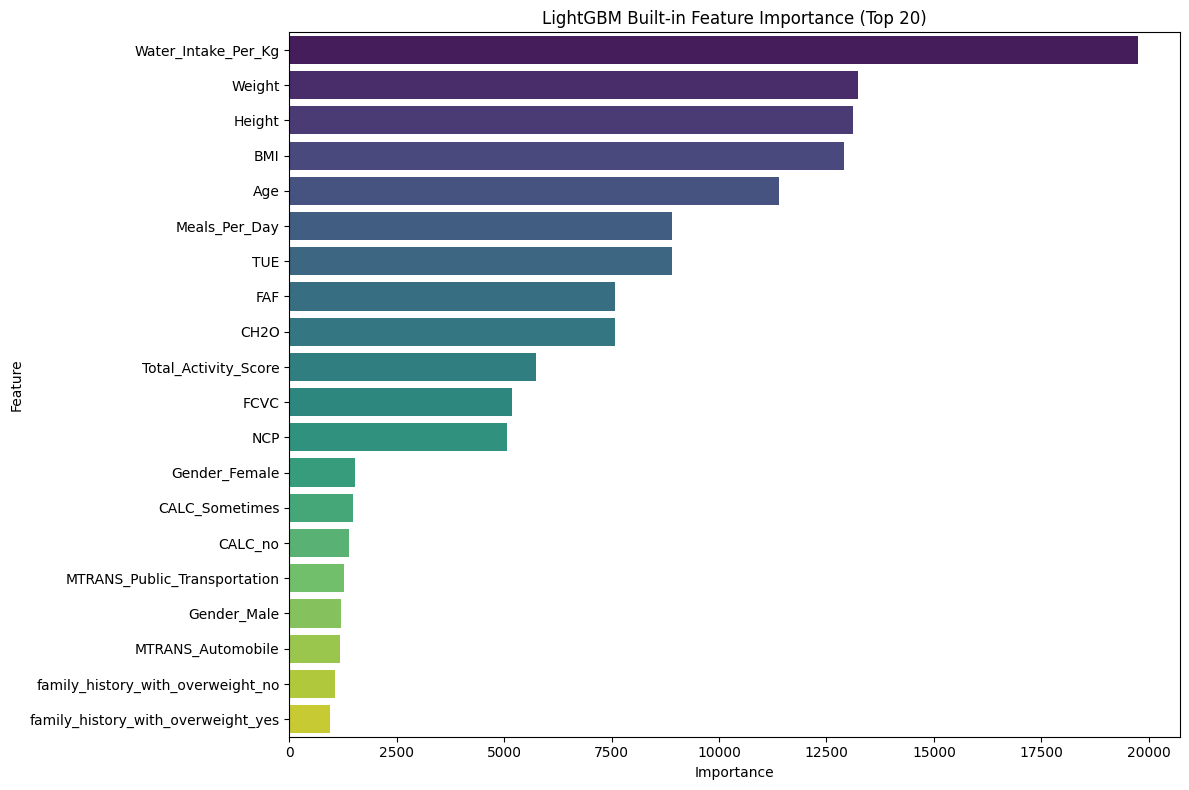

In [154]:

lightgbm_classifier = models['LightGBM'].named_steps['classifier']

feature_importances = lightgbm_classifier.feature_importances_
feature_names = X_TR.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('LightGBM Built-in Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


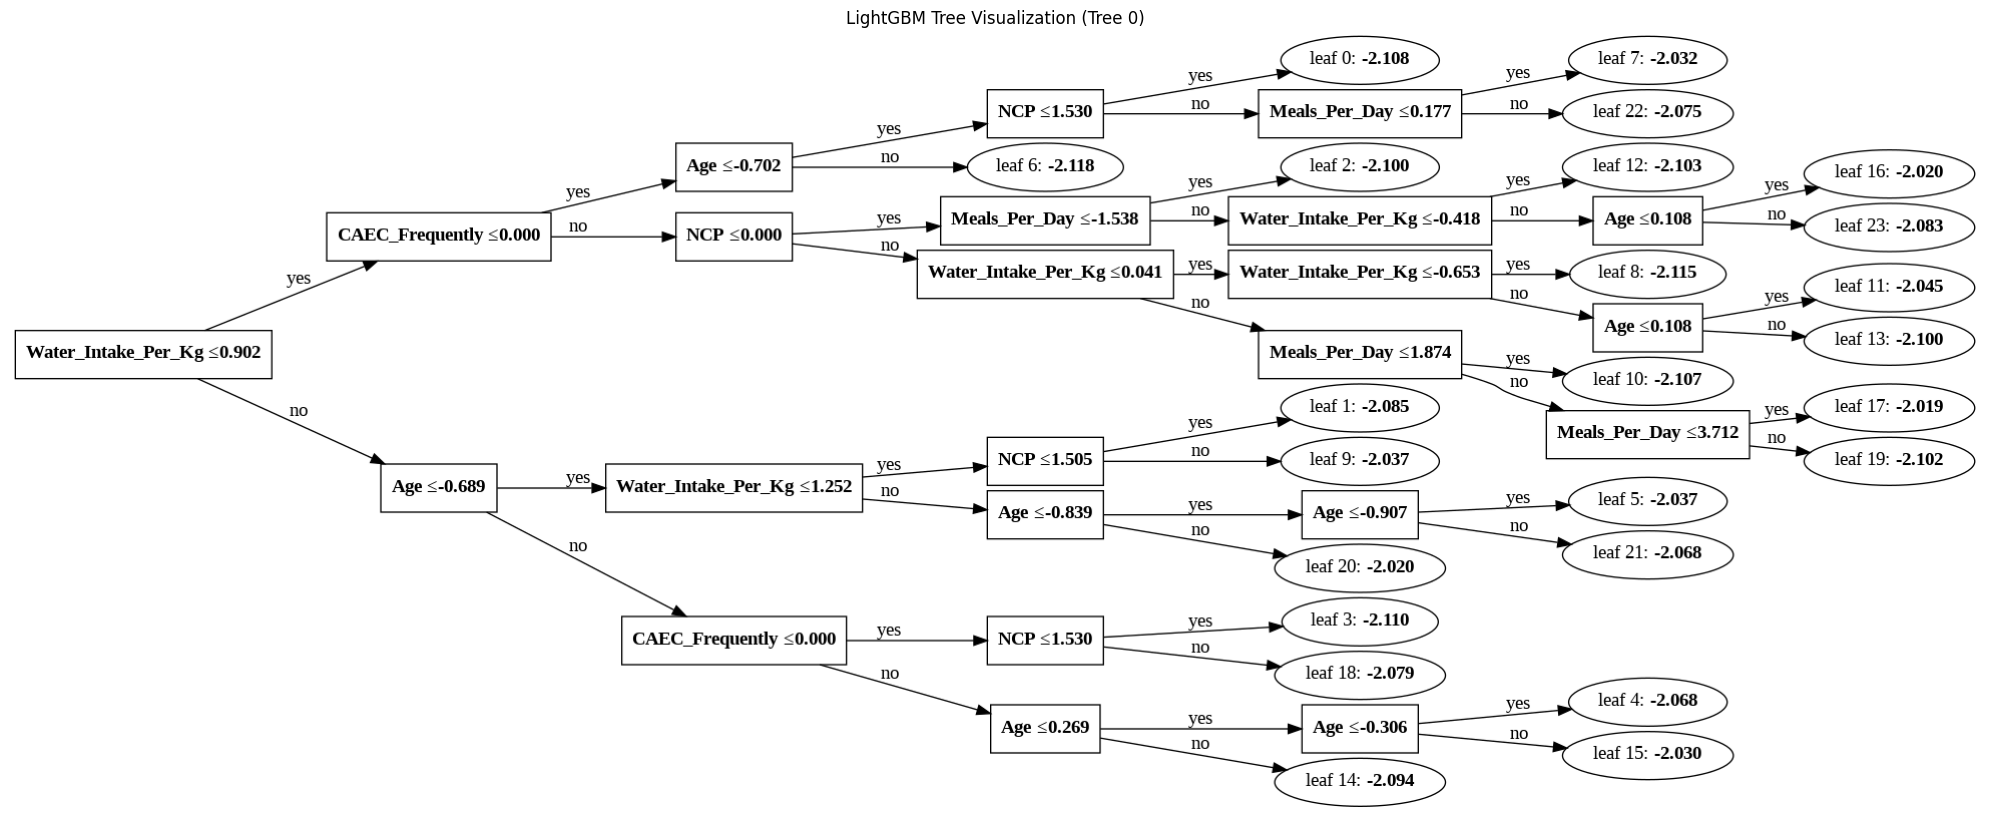

In [157]:
import lightgbm as lgbm # Import lightgbm with the 'lgbm' alias for plotting

lgbm.plot_tree(lightgbm_classifier, tree_index=0, figsize=(20, 10))
plt.title('LightGBM Tree Visualization (Tree 0)')
plt.tight_layout()
plt.show()


## Final Technical Summary

### Model Performance Overview

After training and evaluating multiple classification models for obesity level prediction, including Logistic Regression, Random Forest, Decision Tree, K-Nearest Neighbors, LightGBM, and CatBoost, the following performance highlights were observed:

*   **LightGBM** emerged as the top performer, achieving the highest initial accuracy on the test set (`0.9164`) and strong cross-validation accuracy (`0.9146 \pm 0.0111`). Its precision, recall, and F1-score were also consistently high across all classes.
*   **Random Forest** and **CatBoost** also performed very well, with initial accuracies around `0.9068` and `0.9072` respectively, and comparable cross-validation scores (`0.9060 \pm 0.0132` for Random Forest and `0.9100 \pm 0.0114` for CatBoost).
*   **Logistic Regression** provided a solid baseline, with an initial accuracy of `0.8670` and cross-validation accuracy of `0.8722 \pm 0.0093`.
*   **Decision Tree** and **K-Nearest Neighbors** showed lower performance, with initial accuracies of `0.8486` and `0.7829` respectively, and lower cross-validation scores. This suggests they might be less effective in capturing the complex patterns in this dataset compared to ensemble methods.

### Key Insights from Feature Importance

Both SHAP values and LightGBM's built-in feature importance highlighted the following as the most influential factors in predicting obesity levels:

*   **Weight, Height, and BMI**: These features, as expected, are highly correlated with obesity and significantly impact predictions.
*   **Water_Intake_Per_Kg**: The engineered feature for water intake relative to body weight showed considerable importance.
*   **Age**: Age plays a crucial role in determining obesity levels.
*   **Family History, Physical Activity (FAF), and Meals_Per_Day**: These features also contribute significantly, aligning with known health factors related to obesity.

### Overall Conclusion and Next Steps

The ensemble models, particularly **LightGBM**, demonstrated superior performance, indicating that the dataset benefits from models capable of handling complex, non-linear relationships. The careful preprocessing, including feature engineering, scaling, and one-hot encoding, contributed significantly to these results.

For future work, further hyperparameter tuning using `GridSearchCV` or `RandomizedSearchCV` on the top-performing models (LightGBM, CatBoost, and Random Forest) could yield even better performance. Additionally, investigating potential class imbalances more deeply and evaluating with metrics specifically designed for imbalanced classification could provide further insights into model strengths and weaknesses across all obesity levels.

# Task
Perform hyperparameter tuning for LightGBM using `GridSearchCV` and for Random Forest using `RandomizedSearchCV`. Define appropriate parameter grids for each model, execute the search with cross-validation on the full training data (`X_T`, `y_T`), and then print the best parameters and best cross-validation scores found for both models.

## Prepare for Hyperparameter Tuning

### Subtask:
Import `GridSearchCV` and `RandomizedSearchCV` from `sklearn.model_selection`. Define appropriate parameter grids for LightGBM using `param_grid_lgbm` and for Random Forest using `param_dist_rf`.


**Reasoning**:
Importing GridSearchCV and RandomizedSearchCV and defining parameter grids for LightGBM and Random Forest for hyperparameter tuning as requested.



In [158]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Parameter grid for LightGBM (for GridSearchCV or RandomizedSearchCV)
param_grid_lgbm = {
    'classifier__n_estimators': [500, 700, 900, 1000],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [10, 15, 20],
    'classifier__num_leaves': [20, 30, 40],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9],
    'classifier__reg_alpha': [0.1, 0.5, 1.0],
    'classifier__reg_lambda': [0.1, 0.5, 1.0]
}

# Parameter distribution for Random Forest (for RandomizedSearchCV)
param_dist_rf = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_features': ['sqrt', 'log2', 0.8, 1.0],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

print("GridSearchCV and RandomizedSearchCV imported and parameter grids defined.")

GridSearchCV and RandomizedSearchCV imported and parameter grids defined.


**Reasoning**:
Initialize and perform GridSearchCV for LightGBM using the defined parameter grid.



In [ ]:
print_boxed_blue_heading("Performing GridSearchCV for LightGBM...")

lgbm_grid_search = GridSearchCV(models['LightGBM'], param_grid_lgbm, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
lgbm_grid_search.fit(X_T, y_T)

PrintColor(f"Best parameters for LightGBM: {lgbm_grid_search.best_params_}", Fore.GREEN)
PrintColor(f"Best cross-validation score for LightGBM: {lgbm_grid_search.best_score_:.4f}", Fore.GREEN)


| Performing GridSearchCV for LightGBM... |
Fitting 3 folds for each of 8748 candidates, totalling 26244 fits
